In [1]:

using ImageFiltering

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


gaussian_smooth (generic function with 1 method)

In [2]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title="Superposed Contours",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.6
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(1200,800))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24
    )

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in [  "JUNO6", "Combined Projection"]

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[idx]
        end
    

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=colors[i],
            linewidth=4.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in [ "JUNO6", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=4.5,
                    linestyle=force_dashed ? :dash : :solid
                )
            )

            push!(legend_labels, label)
        end
     

        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:top,
            labelsize=22
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

In [3]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.8
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(1200,800))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=4.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=4.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,4,5,6,9,10]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=22
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

In [4]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=1.0
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width (unchanged)

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 18,
        xlabelsize = 16,
        ylabelsize = 16,
        xticklabelsize = 14,
        yticklabelsize = 14
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=2.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,4,5,6,9,10]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=14
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning:

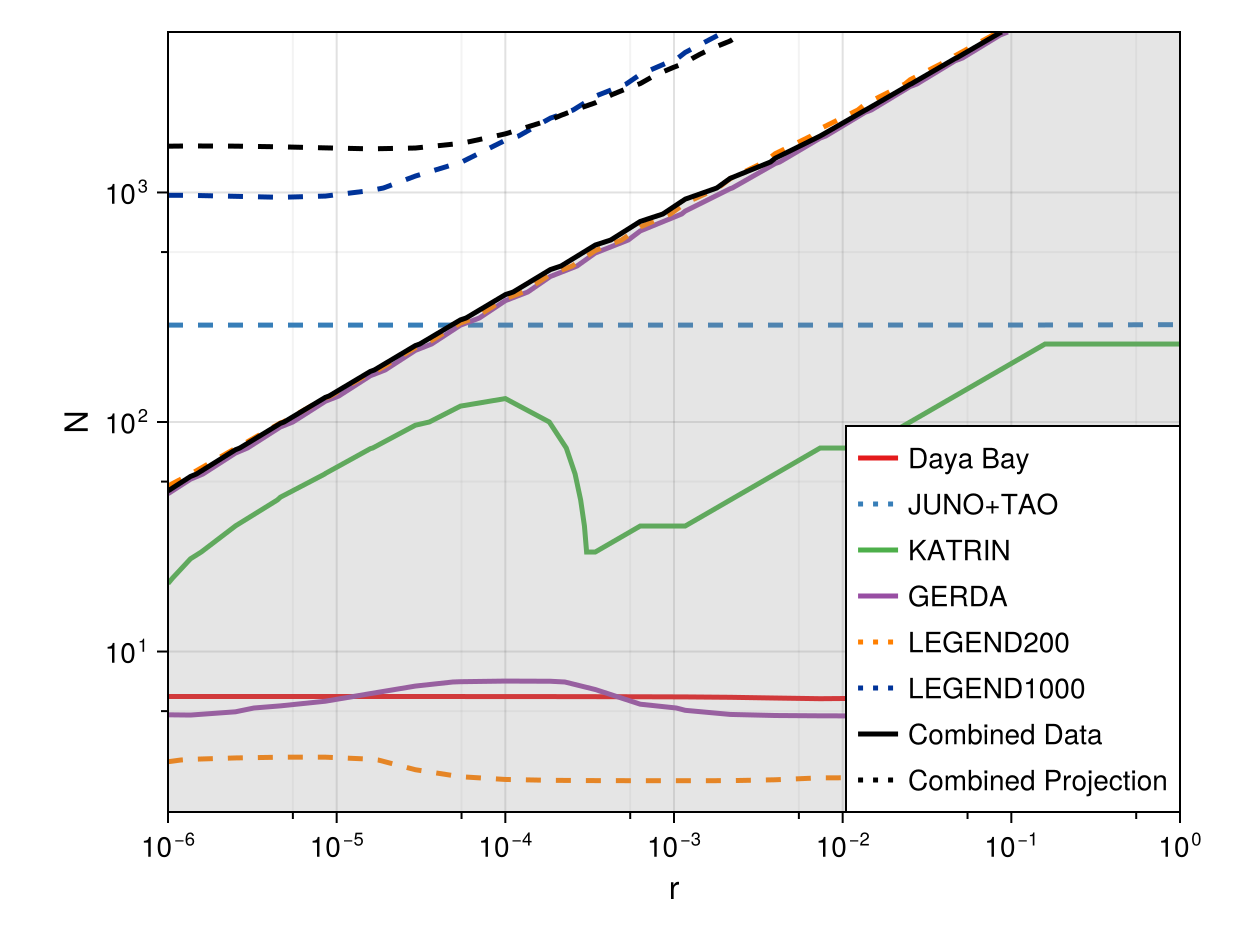

CairoMakie.Screen{SVG}


In [5]:

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NNM_NO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/gerda5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend200_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend1000_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NNM_NO_prof_log_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10, 
    xlims = (1e-6, 1e0),
   title=nothing,#"Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Projection"],
   smooth_sigma=0.8
  
)

display(fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_NO_new.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_NO_new.svg", fig)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning:

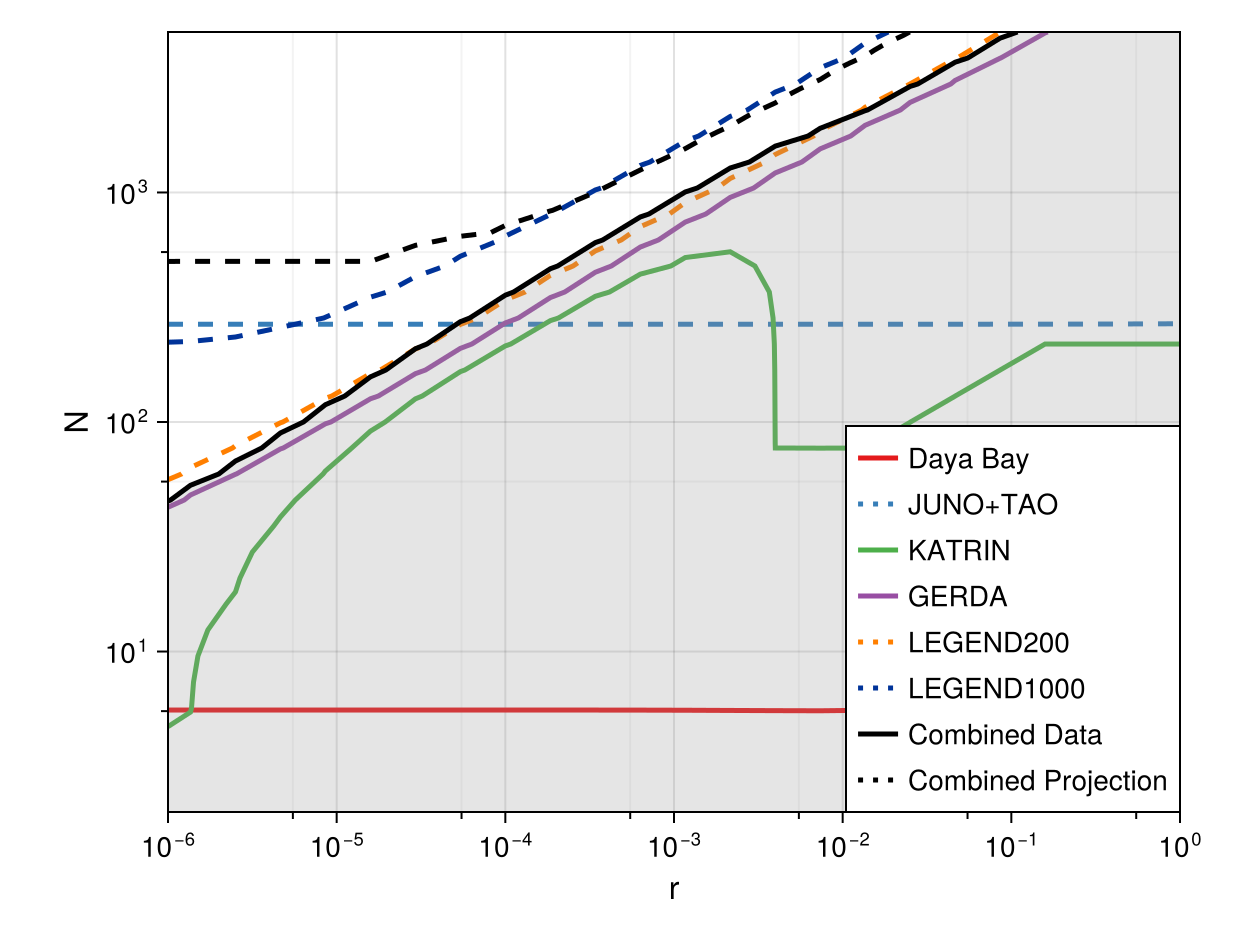

CairoMakie.Screen{IMAGE}


In [6]:

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NNM_IO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/gerda5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend200_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend1000_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NNM_IO_prof_log_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
    xlims = (1e-6, 1e0),
   title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Projection"],
  smooth_sigma=0.8
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_IO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_IO_new.svg", fig)

In [7]:

using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.8
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(1200,800))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
            titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width
    
    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=4.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNOTAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=4.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,6,7]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:top,
            labelsize=22
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

In [8]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.2
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 18,
        xlabelsize = 16,
        ylabelsize = 16,
        xticklabelsize = 14,
        yticklabelsize = 14
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width
    
    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNOTAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=2.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,6,7]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:bottom,
            labelsize=14,  # Increased from 9 to 14 (matches tick labels)
            framevisible=true,
            backgroundcolor=(:white, 0.95),
            strokecolor=:black,
            strokewidth=0.5
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


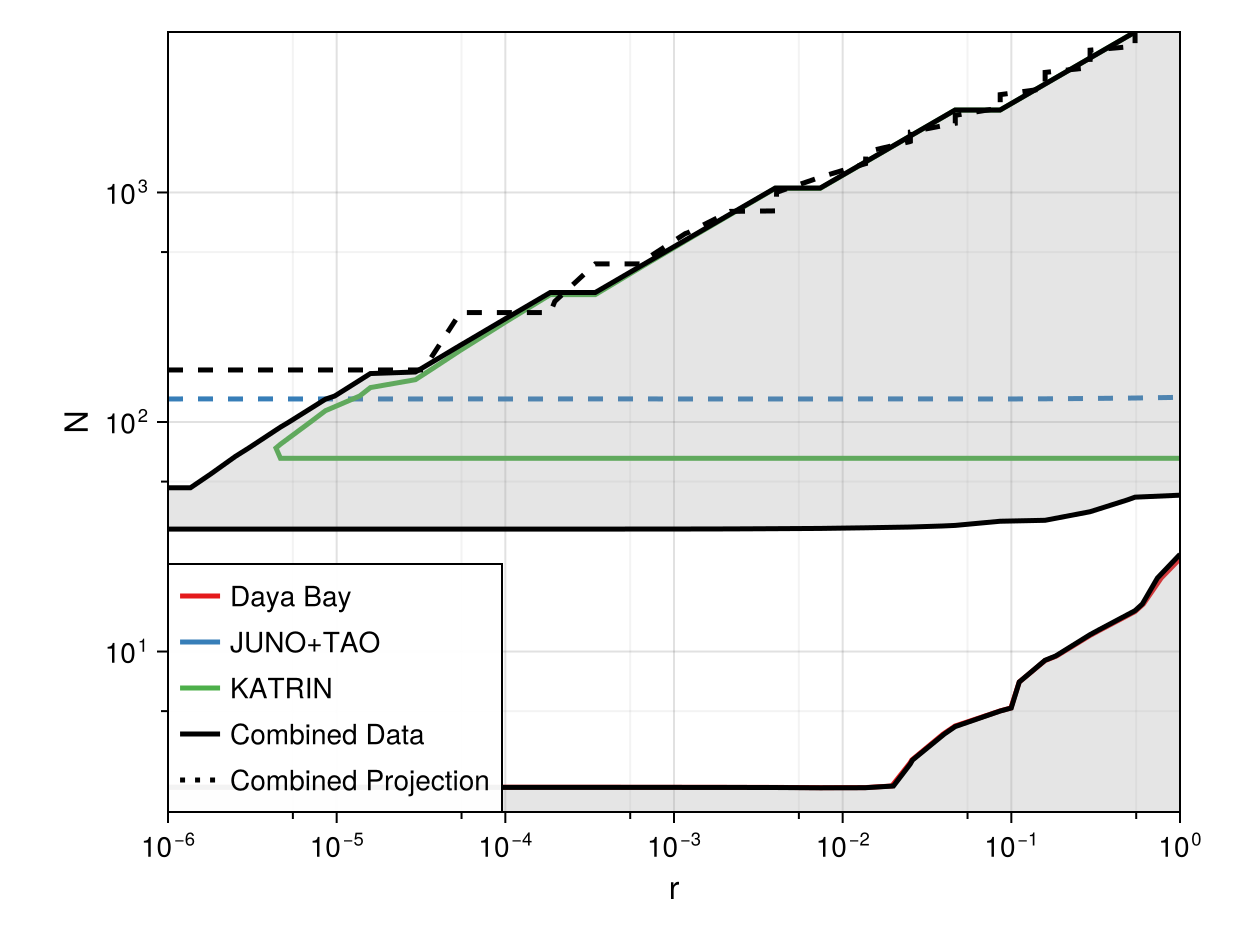

CairoMakie.Screen{IMAGE}


In [9]:

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NND_IO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NND_IO_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
    xlims = (1e-6, 1e0),
     
   title=nothing,#"Dirac IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","Combined Data", "Combined Projection"],
   smooth_sigma=0.2

  
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_IO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_IO_new.svg", fig)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


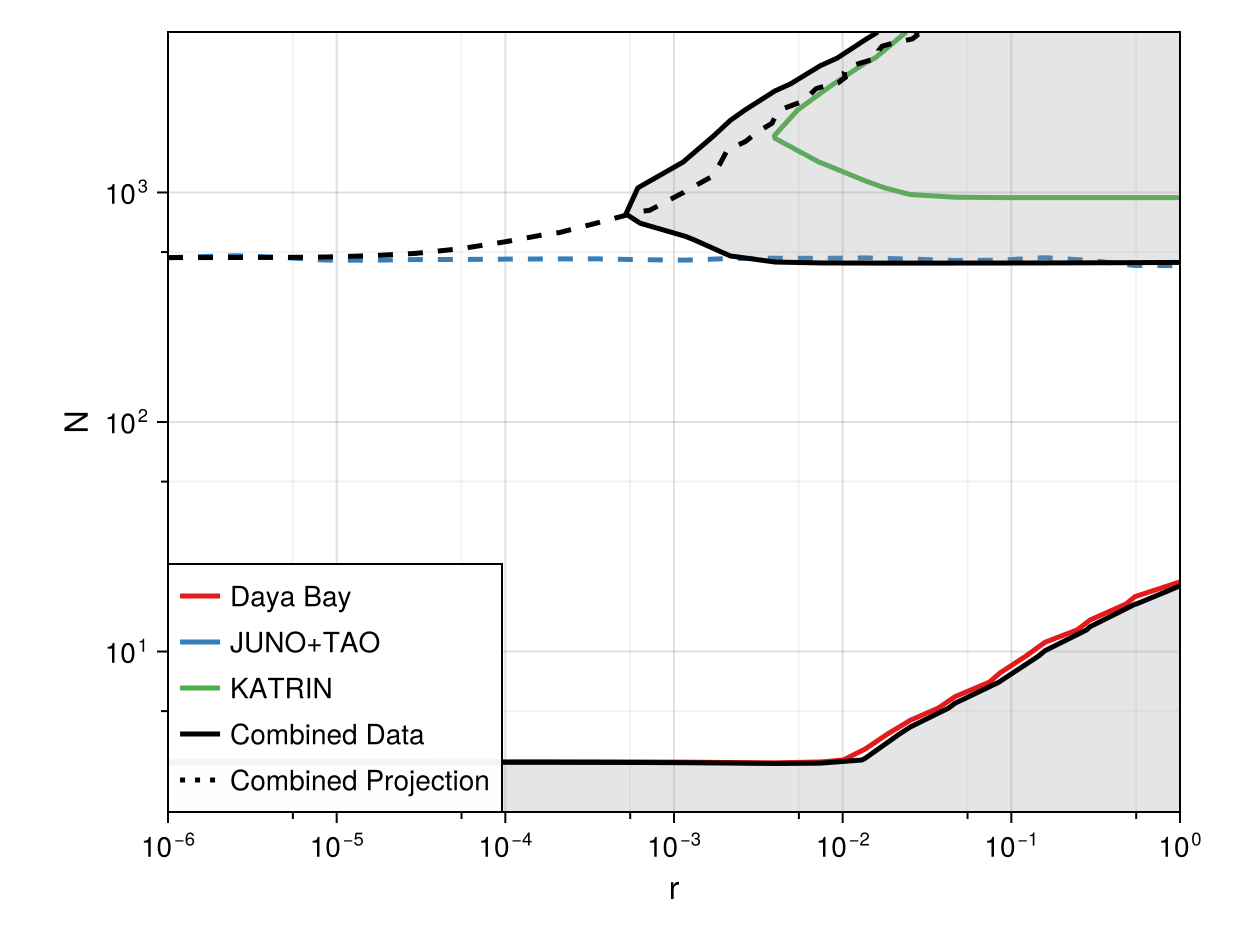

CairoMakie.Screen{SVG}


In [ ]:

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NND_NO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_logdamp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NND_NO_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
     xlims = (1e-6, 1e0),
     title=nothing,#"Dirac NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","Combined Data", "Combined Projection"],
   smooth_sigma=0.8

  
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_NO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_NO_new.svg", fig)

In [11]:
using JLD2
using Statistics

# File paths
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_logdamp_m0=0.01.jld2"

println("=== COMPARING GRIDS AND LOG-POSTERIOR ===\n")

# Load results
katrin_data = load(katrin_file)
global_data = load(global_file)

# Extract result objects (using same logic as your plotting function)
katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))

# Get grids
katrin_r = katrin_result.axes[1]
katrin_N = katrin_result.axes[2]
global_r = global_result.axes[1]
global_N = global_result.axes[2]

# Get log_posterior matrices
katrin_logp = katrin_result.values.log_posterior
global_logp = global_result.values.log_posterior

println("=== GRID COMPARISON ===\n")

println("KATRIN scan:")
println("  r: length=$(length(katrin_r)), range=[$(minimum(katrin_r)), $(maximum(katrin_r))]")
println("  N: length=$(length(katrin_N)), range=[$(minimum(katrin_N)), $(maximum(katrin_N))]")
println("  r spacing: $(katrin_r[2]-katrin_r[1]) (log scale? check: diff(log10.(katrin_r)) = $(diff(log10.(katrin_r))[1:min(3,end)]))")
println("  N spacing: $(katrin_N[2]-katrin_N[1])")

println("\nGLOBAL scan:")
println("  r: length=$(length(global_r)), range=[$(minimum(global_r)), $(maximum(global_r))]")
println("  N: length=$(length(global_N)), range=[$(minimum(global_N)), $(maximum(global_N))]")
println("  r spacing: $(global_r[2]-global_r[1])")
println("  N spacing: $(global_N[2]-global_N[1])")

# Check if grids are identical
println("\n=== IDENTITY CHECK ===\n")

r_identical = length(katrin_r) == length(global_r) && all(katrin_r .≈ global_r)
N_identical = length(katrin_N) == length(global_N) && all(katrin_N .≈ global_N)

if r_identical && N_identical
    println("✓✓✓ GRIDS ARE IDENTICAL! ✓✓✓")
    println("  Both scans used exactly the same grid points")
    
    # Now check if log_posterior difference is constant
    diff_matrix = katrin_logp .- global_logp
    finite_mask = isfinite.(diff_matrix)
    diff_finite = diff_matrix[finite_mask]
    
    println("\n=== LOG-POSTERIOR COMPARISON (same grid) ===\n")
    println("Mean difference: $(mean(diff_finite))")
    println("Std deviation of difference: $(std(diff_finite))")
    println("Max difference: $(maximum(diff_finite))")
    println("Min difference: $(minimum(diff_finite))")
    
    if std(diff_finite) < 1e-6
        println("\n✓✓✓ DIFFERENCE IS CONSTANT across the grid! ✓✓✓")
        println("    Constant offset = $(mean(diff_finite))")
        if mean(diff_finite) < 0
            println("\n    → GLOBAL log-posterior is LOWER by $(abs(mean(diff_finite)))")
            println("    → This explains why the contour is LARGER (worse constraint)")
            println("    → The offset comes from DayaBay contribution (priors or likelihood normalization)")
        end
    else
        println("\n✗ Difference varies across grid (non-constant)")
        println("  This suggests the likelihood shapes are actually different")
    end
    
else
    println("✗✗✗ GRIDS ARE DIFFERENT! ✗✗✗\n")
    
    if !r_identical
        println("R grids differ:")
        println("  KATRIN: $(length(katrin_r)) points from $(minimum(katrin_r)) to $(maximum(katrin_r))")
        println("  GLOBAL: $(length(global_r)) points from $(minimum(global_r)) to $(maximum(global_r))")
        
        # Find common range
        r_min_common = max(minimum(katrin_r), minimum(global_r))
        r_max_common = min(maximum(katrin_r), maximum(global_r))
        println("  Common range: [$r_min_common, $r_max_common]")
        
        # Check if it's just a shift in bounds
        if length(katrin_r) == length(global_r) && 
           abs((maximum(katrin_r)-minimum(katrin_r)) - (maximum(global_r)-minimum(global_r))) < 1e-6
            println("  → Same number of points and range width, but different absolute positions")
            println("  → Shift amount: $(katrin_r[1] - global_r[1])")
        end
    end
    
    if !N_identical
        println("\nN grids differ:")
        println("  KATRIN: $(length(katrin_N)) points from $(minimum(katrin_N)) to $(maximum(katrin_N))")
        println("  GLOBAL: $(length(global_N)) points from $(minimum(global_N)) to $(maximum(global_N))")
    end
    
    println("\n=== FIND BESTFIT POINTS ===\n")
    
    # Find bestfit in each
    katrin_max_idx = argmax(katrin_logp)
    katrin_best_r = katrin_r[CartesianIndices(katrin_logp)[katrin_max_idx][1]]
    katrin_best_N = katrin_N[CartesianIndices(katrin_logp)[katrin_max_idx][2]]
    katrin_best_val = katrin_logp[katrin_max_idx]
    
    global_max_idx = argmax(global_logp)
    global_best_r = global_r[CartesianIndices(global_logp)[global_max_idx][1]]
    global_best_N = global_N[CartesianIndices(global_logp)[global_max_idx][2]]
    global_best_val = global_logp[global_max_idx]
    
    println("KATRIN bestfit: r=$(katrin_best_r), N=$(katrin_best_N), logp=$(katrin_best_val)")
    println("GLOBAL bestfit: r=$(global_best_r), N=$(global_best_N), logp=$(global_best_val)")
    println("Difference: Δr=$(katrin_best_r-global_best_r), ΔN=$(katrin_best_N-global_best_N), Δlogp=$(katrin_best_val-global_best_val)")
    
    # Check if bestfit points are at edges
    println("\n=== CHECK FOR EDGE EFFECTS ===")
    katrin_r_idx = CartesianIndices(katrin_logp)[katrin_max_idx][1]
    katrin_N_idx = CartesianIndices(katrin_logp)[katrin_max_idx][2]
    global_r_idx = CartesianIndices(global_logp)[global_max_idx][1]
    global_N_idx = CartesianIndices(global_logp)[global_max_idx][2]
    
    if katrin_r_idx == 1 || katrin_r_idx == length(katrin_r)
        println("  ⚠️ KATRIN bestfit is at R grid EDGE!")
    end
    if katrin_N_idx == 1 || katrin_N_idx == length(katrin_N)
        println("  ⚠️ KATRIN bestfit is at N grid EDGE!")
    end
    if global_r_idx == 1 || global_r_idx == length(global_r)
        println("  ⚠️ GLOBAL bestfit is at R grid EDGE!")
    end
    if global_N_idx == 1 || global_N_idx == length(global_N)
        println("  ⚠️ GLOBAL bestfit is at N grid EDGE!")
    end
end

println("\n=== DIAGNOSIS ===\n")
if r_identical && N_identical
    if std(diff_finite) < 1e-6
        println("PROBLEM: Constant offset in log-posterior")
        println("SOLUTION: Check DayaBay likelihood normalization or prior contributions")
    else
        println("PROBLEM: Log-posterior shapes differ on identical grid")
        println("SOLUTION: Check if DayaBay has unintended sensitivity to r/N")
    end
else
    println("PROBLEM: Different grids used between scans")
    println("SOLUTION: Force explicit identical grids in both scans")
    println("\nTo fix, define grids explicitly:")
    println("  r_grid = range(1e-8, 1.0, length=31)")
    println("  N_grid = range(2.0, 5000.0, length=31)")
    println("  vars_to_scan = (r = r_grid, N = N_grid)")
end

=== COMPARING GRIDS AND LOG-POSTERIOR ===



┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


=== GRID COMPARISON ===

KATRIN scan:
  r: length=31, range=[1.0e-8, 1.0000000000000018]
  N: length=31, range=[2.0, 4999.999999999999]
  r spacing: 8.478497974222913e-9 (log scale? check: diff(log10.(katrin_r)) = [0.2666666666666666, 0.2666666666666666, 0.2666666666666666])
  N spacing: 0.5959400731046531

GLOBAL scan:
  r: length=31, range=[1.0e-8, 1.0000000000000018]
  N: length=31, range=[2.0, 4999.999999999999]
  r spacing: 8.478497974222913e-9
  N spacing: 0.5959400731046531

=== IDENTITY CHECK ===

✓✓✓ GRIDS ARE IDENTICAL! ✓✓✓
  Both scans used exactly the same grid points

=== LOG-POSTERIOR COMPARISON (same grid) ===

Mean difference: 191.55562830736665
Std deviation of difference: 258.78744356304577
Max difference: 5877.393523931947
Min difference: 167.65086969946822

✗ Difference varies across grid (non-constant)
  This suggests the likelihood shapes are actually different

=== DIAGNOSIS ===

PROBLEM: Log-posterior shapes differ on identical grid
SOLUTION: Check if DayaBay ha

In [12]:
using JLD2
using Statistics

katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_logdamp_m0=0.01.jld2"

# Load
katrin_data = load(katrin_file)
global_data = load(global_file)

katrin_result = katrin_data["result"]
global_result = global_data["result"]

# Get bestfit indices
katrin_best = argmax(katrin_result.values.log_posterior)
global_best = argmax(global_result.values.log_posterior)

# Get bestfit coordinates
katrin_r_best = katrin_result.axes[1][CartesianIndices(katrin_result.values.log_posterior)[katrin_best][1]]
katrin_N_best = katrin_result.axes[2][CartesianIndices(katrin_result.values.log_posterior)[katrin_best][2]]

global_r_best = global_result.axes[1][CartesianIndices(global_result.values.log_posterior)[global_best][1]]
global_N_best = global_result.axes[2][CartesianIndices(global_result.values.log_posterior)[global_best][2]]

println("=== BESTFIT POINTS ===")
println("KATRIN-only: r = $katrin_r_best, N = $katrin_N_best")
println("Combined:    r = $global_r_best, N = $global_N_best")
println("Difference:  Δr = $(katrin_r_best - global_r_best), ΔN = $(katrin_N_best - global_N_best)")

# Also get the actual likelihood values
katrin_best_logp = katrin_result.values.log_posterior[katrin_best]
global_best_logp = global_result.values.log_posterior[global_best]

println("\n=== LOG-POSTERIOR VALUES ===")
println("KATRIN-only best: $katrin_best_logp")
println("Combined best:    $global_best_logp")
println("Difference:       $(katrin_best_logp - global_best_logp)")

# Check if bestfit is at edge of grid (indicates grid problem)
katrin_r_idx = CartesianIndices(katrin_result.values.log_posterior)[katrin_best][1]
katrin_N_idx = CartesianIndices(katrin_result.values.log_posterior)[katrin_best][2]
global_r_idx = CartesianIndices(global_result.values.log_posterior)[global_best][1]
global_N_idx = CartesianIndices(global_result.values.log_posterior)[global_best][2]

println("\n=== GRID POSITION ===")
println("KATRIN: r index $(katrin_r_idx)/$(length(katrin_result.axes[1])), N index $(katrin_N_idx)/$(length(katrin_result.axes[2]))")
println("GLOBAL: r index $(global_r_idx)/$(length(global_result.axes[1])), N index $(global_N_idx)/$(length(global_result.axes[2]))")

if katrin_r_idx == 1 || katrin_r_idx == length(katrin_result.axes[1])
    println("⚠️ KATRIN bestfit at r grid EDGE - grid might not capture true minimum")
end
if global_r_idx == 1 || global_r_idx == length(global_result.axes[1])
    println("⚠️ GLOBAL bestfit at r grid EDGE - grid might not capture true minimum")
end

=== BESTFIT POINTS ===


┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


KATRIN-only: r = 1.0e-8, N = 4999.999999999999
Combined:    r = 0.02511886431509587, N = 5.676604844324337
Difference:  Δr = -0.02511885431509587, ΔN = 4994.323395155675

=== LOG-POSTERIOR VALUES ===
KATRIN-only best: 0.5399530744978267
Combined best:    -167.1178278470911
Difference:       167.6577809215889

=== GRID POSITION ===
KATRIN: r index 1/31, N index 31/31
GLOBAL: r index 25/31, N index 5/31
⚠️ KATRIN bestfit at r grid EDGE - grid might not capture true minimum


┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbo

Saved to: likelihood_comparison.png


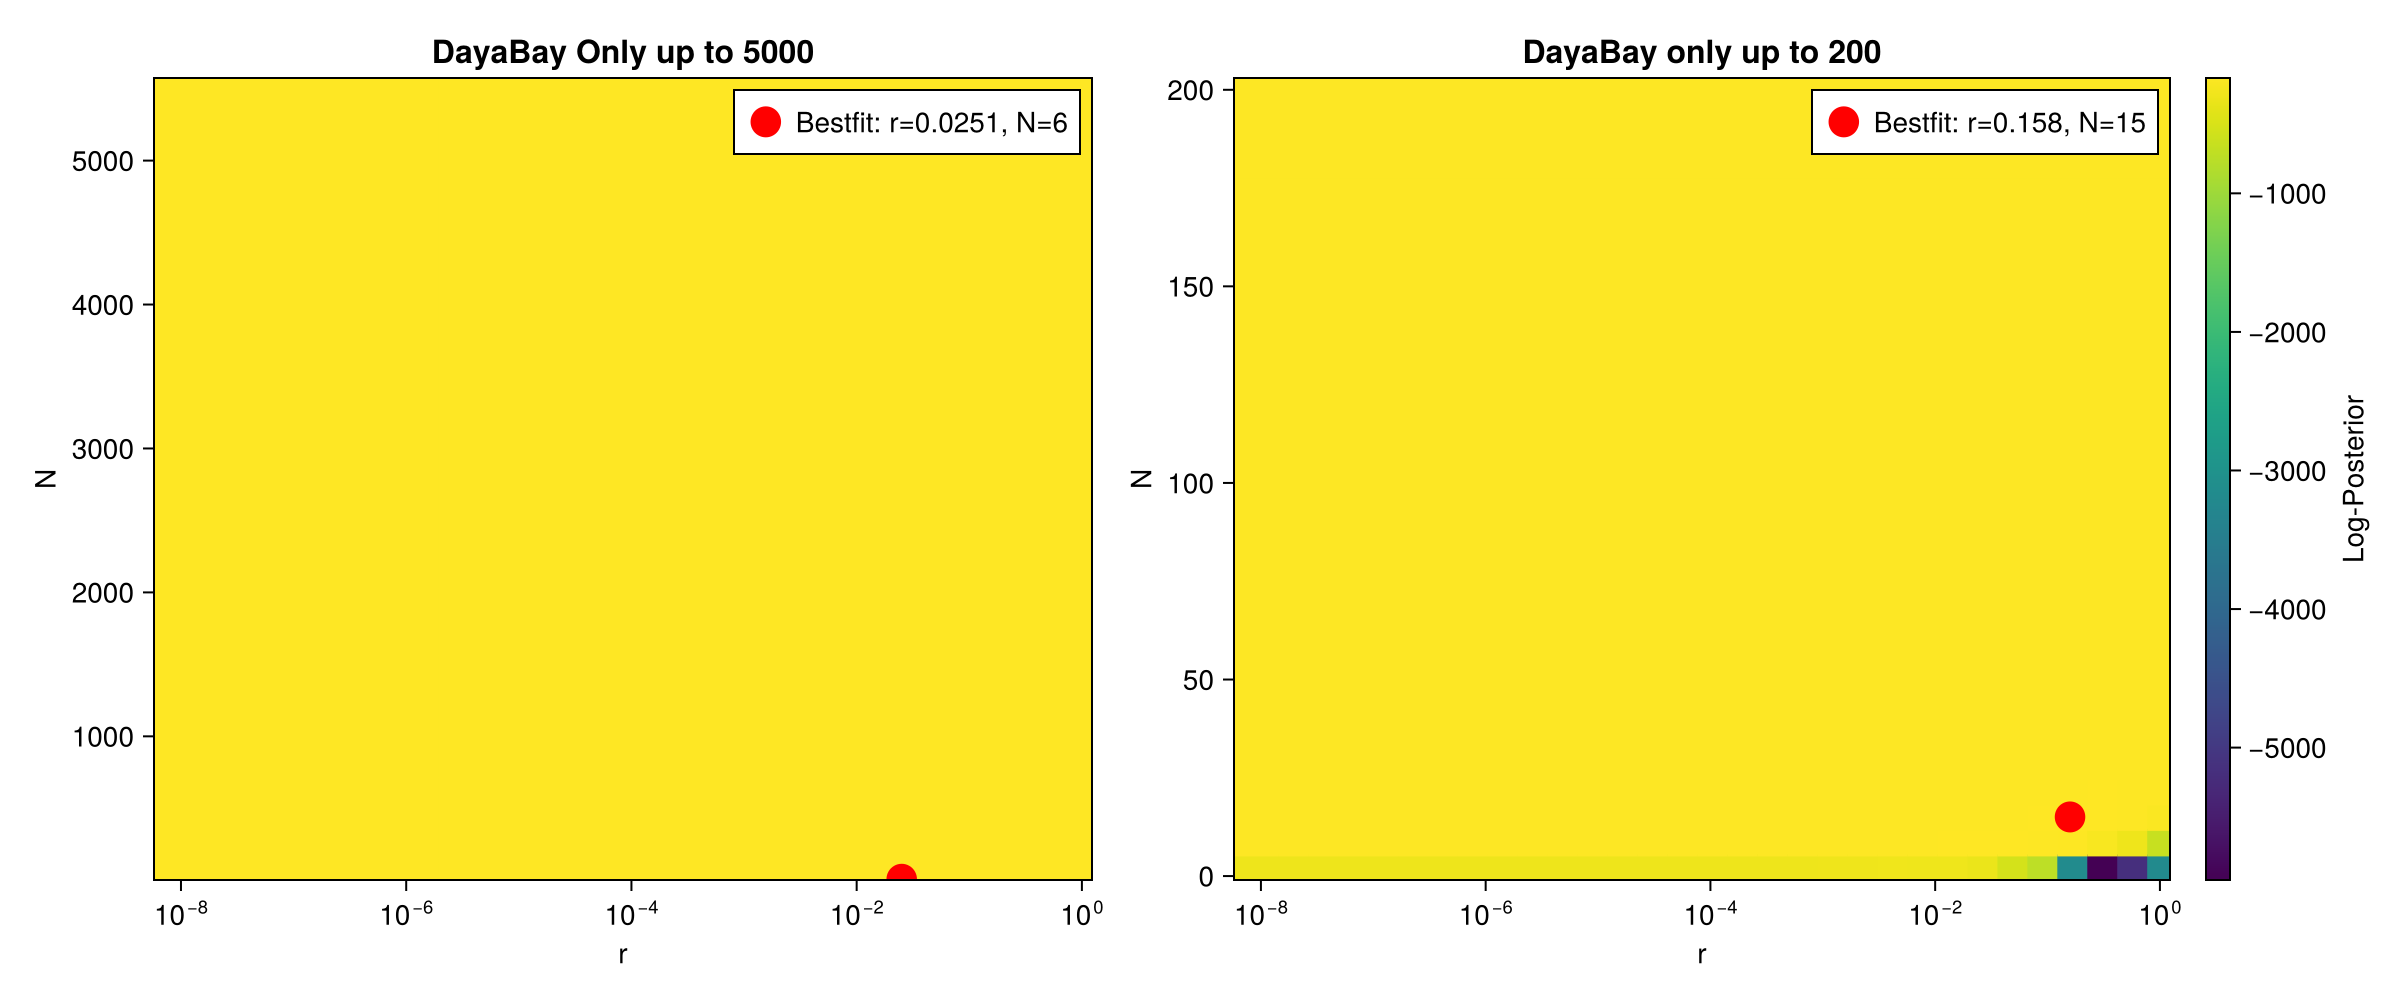

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can

Grids are different - cannot compute direct difference
KATRIN r range: (1.0e-8, 1.0000000000000018), N range: (2.0, 4999.999999999999)
GLOBAL r range: (1.0e-8, 1.0000000000000018), N range: (2, 200)


nothing

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


Saved to: likelihood_shared_colorbar.png


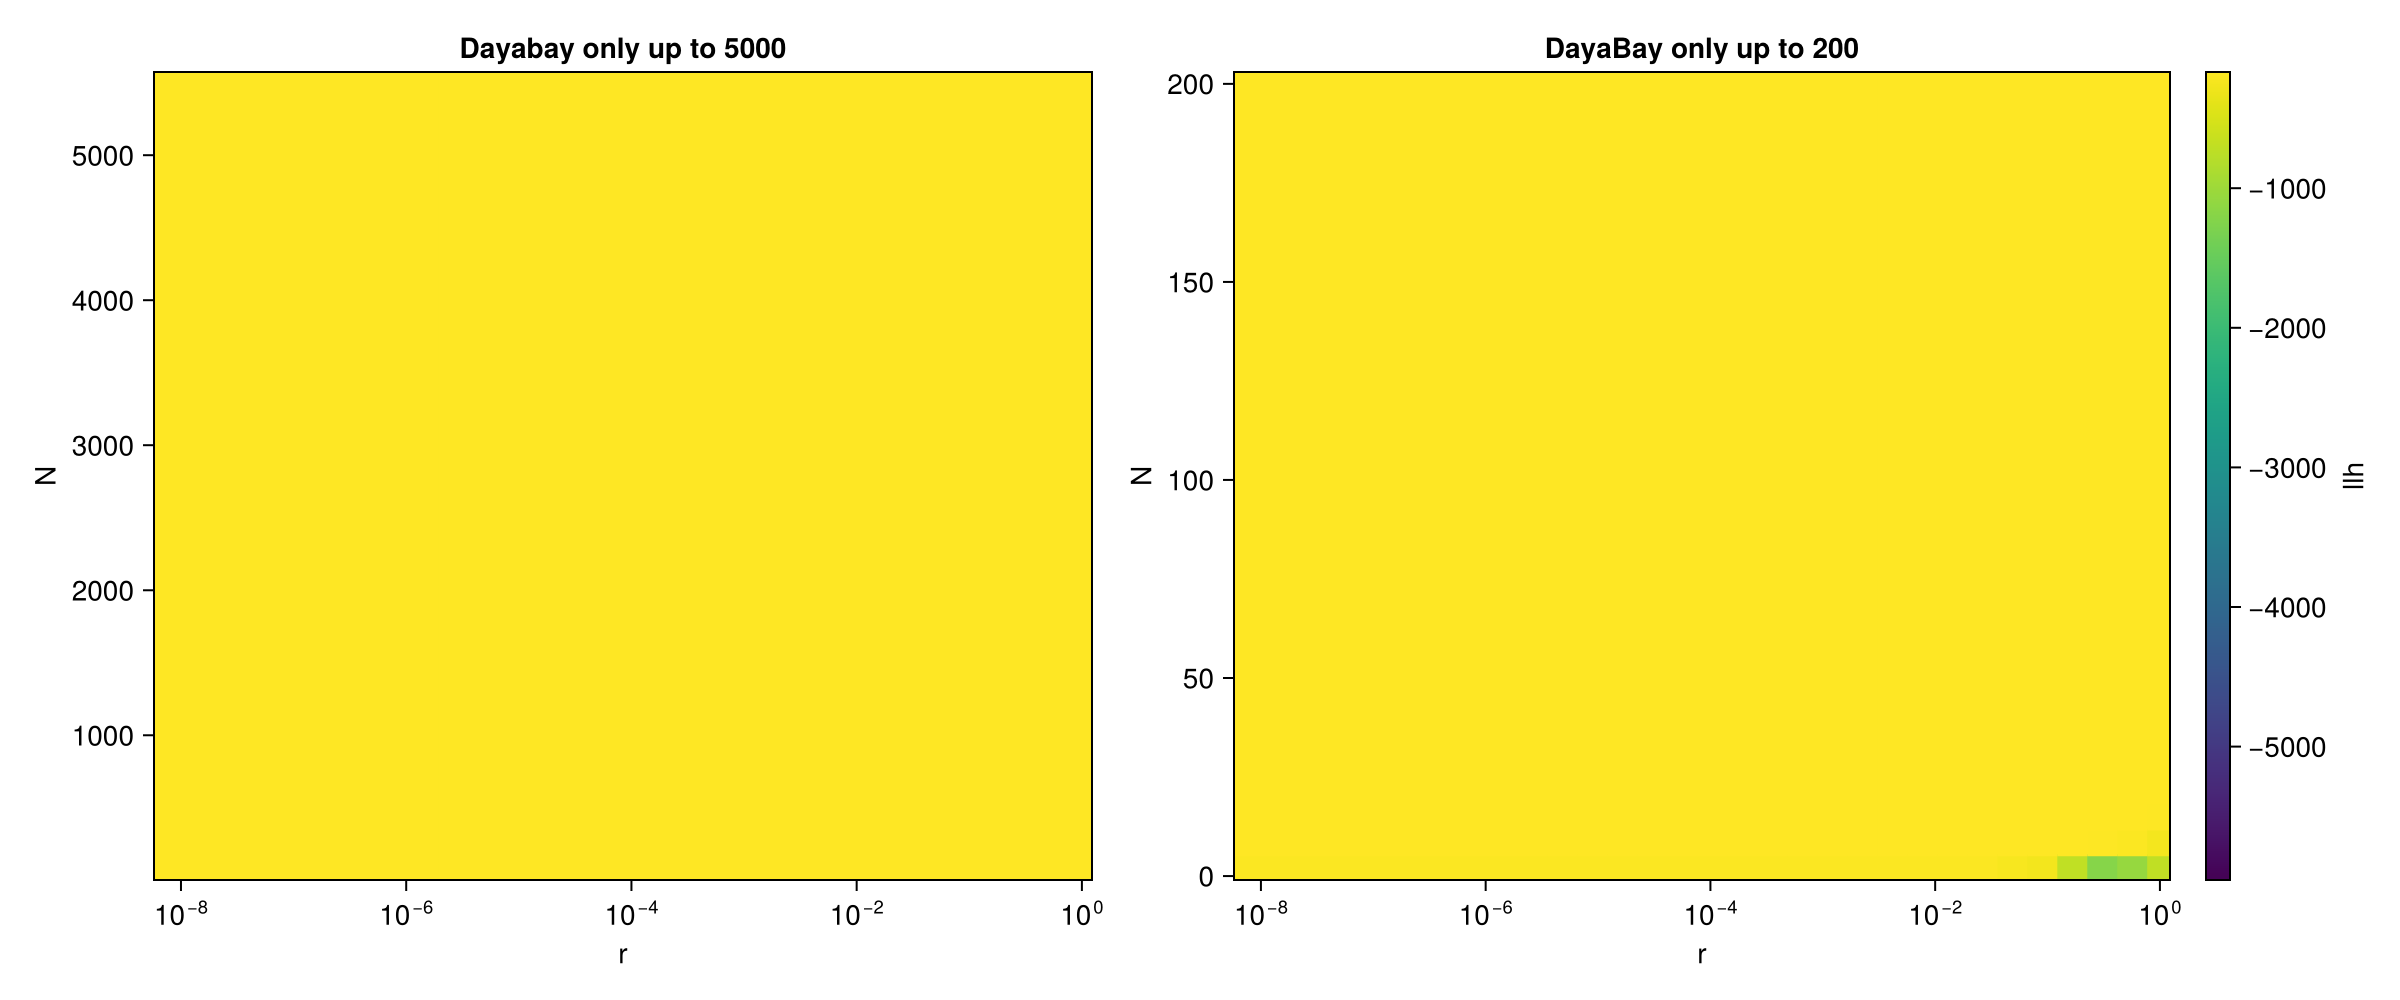

CairoMakie.Screen{IMAGE}


In [13]:
using JLD2
using CairoMakie
using ColorSchemes

function plot_likelihood_colormaps(
    katrin_file::String,
    global_file::String;
    title_katrin = "DayaBay Only up to 5000",
    title_global = "DayaBay only up to 200",
    save_path = nothing,
    log_scale_r = true,
    levels = nothing
)
    # Load data
    katrin_data = load(katrin_file)
    global_data = load(global_file)
    
    # Extract results
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    # Get grids and log-posterior
    r_katrin = katrin_result.axes[1]
    N_katrin = katrin_result.axes[2]
    logp_katrin = katrin_result.values.log_posterior
    
    r_global = global_result.axes[1]
    N_global = global_result.axes[2]
    logp_global = global_result.values.llh
    
    # Handle potential infinite/NaN values
    logp_katrin_clean = copy(logp_katrin)
    logp_global_clean = copy(logp_global)
    logp_katrin_clean[.!isfinite.(logp_katrin_clean)] .= NaN
    logp_global_clean[.!isfinite.(logp_global_clean)] .= NaN
    
    # Find bestfit points
    katrin_best_idx = argmax(logp_katrin_clean)
    global_best_idx = argmax(logp_global_clean)
    
    katrin_best_r = r_katrin[CartesianIndices(logp_katrin_clean)[katrin_best_idx][1]]
    katrin_best_N = N_katrin[CartesianIndices(logp_katrin_clean)[katrin_best_idx][2]]
    global_best_r = r_global[CartesianIndices(logp_global_clean)[global_best_idx][1]]
    global_best_N = N_global[CartesianIndices(logp_global_clean)[global_best_idx][2]]
    
    # Create figure with two panels
    fig = Figure(size=(1200, 500))
    
    # Panel 1: KATRIN only
    ax1 = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = title_katrin,
        xscale = log_scale_r ? log10 : identity,
        yscale = identity,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    # Create colormap
    cmap = cgrad(:viridis)
    
    # Plot heatmap
    hm1 = heatmap!(
        ax1,
        r_katrin,
        N_katrin,
        logp_katrin_clean,
        colormap = cmap,
        interpolate = false
    )
    
    # Mark bestfit point
    scatter!(
        ax1,
        [katrin_best_r],
        [katrin_best_N],
        color = :red,
        marker = :star,
        markersize = 20,
        label = "Bestfit: r=$(round(katrin_best_r, sigdigits=3)), N=$(round(Int, katrin_best_N))"
    )
    
    # Mark edge points if applicable
    if any(isnan.(logp_katrin_clean))
        # Find NaN regions (likely outside prior bounds)
        nan_mask = isnan.(logp_katrin_clean)
        # Could highlight edges where prior cuts off
    end
    
    # Panel 2: Combined
    ax2 = Axis(
        fig[1, 2],
        xlabel = "r",
        ylabel = "N",
        title = title_global,
        xscale = log_scale_r ? log10 : identity,
        yscale = identity,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm2 = heatmap!(
        ax2,
        r_global,
        N_global,
        logp_global_clean,
        colormap = cmap,
        interpolate = false
    )
    
    scatter!(
        ax2,
        [global_best_r],
        [global_best_N],
        color = :red,
        marker = :star,
        markersize = 20,
        label = "Bestfit: r=$(round(global_best_r, sigdigits=3)), N=$(round(Int, global_best_N))"
    )
    
    # Add colorbars
    Colorbar(fig[1, 3], hm1, label = "Log-Posterior")
    
    # Add legends
    axislegend(ax1, position = :rt, framevisible = true)
    axislegend(ax2, position = :rt, framevisible = true)
    
    # Save if requested
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig
end

# Function to plot difference map
function plot_difference_map(
    katrin_file::String,
    global_file::String;
    save_path = nothing,
    log_scale_r = true
)
    # Load data
    katrin_data = load(katrin_file)
    global_data = load(global_file)
    
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    # Get grids
    r_katrin = katrin_result.axes[1]
    N_katrin = katrin_result.axes[2]
    r_global = global_result.axes[1]
    N_global = global_result.axes[2]
    
    # Check if grids are identical
    if length(r_katrin) == length(r_global) && length(N_katrin) == length(N_global) &&
       all(r_katrin .≈ r_global) && all(N_katrin .≈ N_global)
        
        # Same grid - direct subtraction
        logp_katrin = katrin_result.values.log_posterior
        logp_global = global_result.values.log_posterior
        
        # Clean up infinite/NaN
        logp_katrin[.!isfinite.(logp_katrin)] .= NaN
        logp_global[.!isfinite.(logp_global)] .= NaN
        
        diff = logp_global - logp_katrin
        
        fig = Figure(size=(800, 600))
        ax = Axis(
            fig[1, 1],
            xlabel = "r",
            ylabel = "N",
            title = "Difference in Log-Posterior (Combined - KATRIN)",
            xscale = log_scale_r ? log10 : identity,
            yscale = identity
        )
        
        # Diverging colormap for differences
        cmap = cgrad(:RdBu, rev=true)
        max_abs = maximum(abs, diff[isfinite.(diff)])
        
        hm = heatmap!(
            ax,
            r_katrin,
            N_katrin,
            diff,
            colormap = cmap,
            colorrange = (-max_abs, max_abs),
            interpolate = false
        )
        
        Colorbar(fig[1, 2], hm, label = "Δ Log-Posterior")
        
        # Add zero contour line
        contour!(
            ax,
            r_katrin,
            N_katrin,
            diff,
            levels = [0],
            color = :black,
            linewidth = 2,
            linestyle = :dash
        )
        
        if save_path !== nothing
            save(save_path, fig)
            println("Saved to: $save_path")
        end
        
        return fig
        
    else
        println("Grids are different - cannot compute direct difference")
        println("KATRIN r range: $(extrema(r_katrin)), N range: $(extrema(N_katrin))")
        println("GLOBAL r range: $(extrema(r_global)), N range: $(extrema(N_global))")
        return nothing
    end
end

# Function to plot both with same color scale
function plot_combined_colorbar(
    katrin_file::String,
    global_file::String;
    save_path = nothing,
    log_scale_r = true
)
    # Load data
    katrin_data = load(katrin_file)
    global_data = load(global_file)
    
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    # Get log-posteriors
    logp_katrin = katrin_result.values.log_posterior
    logp_global = global_result.values.log_posterior
    
    # Clean up
    logp_katrin[.!isfinite.(logp_katrin)] .= NaN
    logp_global[.!isfinite.(logp_global)] .= NaN
    
    # Find common color range
    min_val = min(minimum(skipmissing(logp_katrin)), minimum(skipmissing(logp_global)))
    max_val = max(maximum(skipmissing(logp_katrin)), maximum(skipmissing(logp_global)))
    
    # Create figure
    fig = Figure(size=(1200, 500))
    
    # Panel 1
    ax1 = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "Dayabay only up to 5000",
        xscale = log_scale_r ? log10 : identity,
        titlesize = 14
    )
    
    hm1 = heatmap!(
        ax1,
        katrin_result.axes[1],
        katrin_result.axes[2],
        logp_katrin,
        colormap = :viridis,
        colorrange = (min_val, max_val),
        interpolate = false
    )
    
    # Panel 2
    ax2 = Axis(
        fig[1, 2],
        xlabel = "r",
        ylabel = "N",
        title = "DayaBay only up to 200",
        xscale = log_scale_r ? log10 : identity,
        titlesize = 14
    )
    
    hm2 = heatmap!(
        ax2,
        global_result.axes[1],
        global_result.axes[2],
        logp_global,
        colormap = :viridis,
        colorrange = (min_val, max_val),
        interpolate = false
    )
    
    # Shared colorbar
    Colorbar(fig[1, 3], hm1, label = "llh")
    
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig
end

# Usage:
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_NO_log_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_NO_log.jld2"#"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_rN_NND_NO_m0=0.01.jld2"  #"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_lognew_m0=0.01.jld2"

# Plot side by side
fig1 = plot_likelihood_colormaps(
    katrin_file, 
    global_file;
    save_path = "likelihood_comparison.png",
    log_scale_r = true
)
display("image/png", fig1)

# Plot difference map (if grids are identical - they are!)
fig2 = plot_difference_map(
    katrin_file, 
    global_file;
    save_path = "likelihood_difference.png",
    log_scale_r = true
)
display(fig2)

# Plot with shared color scale
fig3 = plot_combined_colorbar(
    katrin_file, 
    global_file;
    save_path = "likelihood_shared_colorbar.png",
    log_scale_r = true
)
display(fig3)

In [14]:
using JLD2

# File paths
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_lognew_m0=0.01.jld2"

# Load data
katrin_data = load(katrin_file)
global_data = load(global_file)

# Extract results
katrin_result = katrin_data["result"]
global_result = global_data["result"]

# Get log-posterior matrices
katrin_logp = katrin_result.values.log_posterior
global_logp = global_result.values.log_posterior

# Grid information
r_vals = katrin_result.axes[1]  # r grid
N_vals = katrin_result.axes[2]  # N grid

println("=== GRID INFORMATION ===")
println("r grid: $(length(r_vals)) points from $(r_vals[1]) to $(r_vals[end])")
println("N grid: $(length(N_vals)) points from $(N_vals[1]) to $(N_vals[end])")
println("\nSpecific points:")
println("  r[1] = $(r_vals[1])")
println("  r[31] = $(r_vals[31])")
println("  N[1] = $(N_vals[1])")
println("  N[31] = $(N_vals[31])")

# Find bestfit points
katrin_best_idx = argmax(katrin_logp)
global_best_idx = argmax(global_logp)

katrin_best_r_idx = CartesianIndices(katrin_logp)[katrin_best_idx][1]
katrin_best_N_idx = CartesianIndices(katrin_logp)[katrin_best_idx][2]
katrin_best_r = r_vals[katrin_best_r_idx]
katrin_best_N = N_vals[katrin_best_N_idx]
katrin_best_logp = katrin_logp[katrin_best_idx]

global_best_r_idx = CartesianIndices(global_logp)[global_best_idx][1]
global_best_N_idx = CartesianIndices(global_logp)[global_best_idx][2]
global_best_r = r_vals[global_best_r_idx]
global_best_N = N_vals[global_best_N_idx]
global_best_logp = global_logp[global_best_idx]

println("\n=== BESTFIT POINTS ===")
println("KATRIN bestfit:")
println("  Position: (r_idx=$katrin_best_r_idx, N_idx=$katrin_best_N_idx)")
println("  r = $katrin_best_r, N = $katrin_best_N")
println("  log-posterior = $katrin_best_logp")
println("\nGLOBAL bestfit:")
println("  Position: (r_idx=$global_best_r_idx, N_idx=$global_best_N_idx)")
println("  r = $global_best_r, N = $global_best_N")
println("  log-posterior = $global_best_logp")

# Get log-posterior at grid point (1,31) - r=1e-8, N=5000
# Note: r[1] is smallest r, N[31] is largest N
grid_point_r_idx = 1
grid_point_N_idx = 31

katrin_grid_logp = katrin_logp[grid_point_r_idx, grid_point_N_idx]
global_grid_logp = global_logp[grid_point_r_idx, grid_point_N_idx]

println("\n=== GRID POINT (r_idx=1, N_idx=31) ===")
println("Coordinates:")
println("  r = $(r_vals[grid_point_r_idx])")
println("  N = $(N_vals[grid_point_N_idx])")
println("\nKATRIN log-posterior at this point: $katrin_grid_logp")
println("GLOBAL log-posterior at this point: $global_grid_logp")

# Calculate differences from bestfit
println("\n=== DIFFERENCES FROM BESTFIT (Δlogp = bestfit - gridpoint) ===")
println("\nKATRIN scan:")
katrin_diff = katrin_best_logp - katrin_grid_logp
println("  Δ from KATRIN bestfit to grid point (1,31): $katrin_diff")
println("  (Positive means bestfit is better than grid point)")

println("\nGLOBAL scan:")
global_diff = global_best_logp - global_grid_logp
println("  Δ from GLOBAL bestfit to grid point (1,31): $global_diff")
println("  (Positive means bestfit is better than grid point)")

println("\n=== CROSS-SCAN COMPARISON ===")
println("KATRIN bestfit value at GLOBAL's grid point (1,31): $katrin_grid_logp")
println("GLOBAL bestfit value: $global_best_logp")
println("Difference (GLOBAL bestfit - KATRIN at grid point): $(global_best_logp - katrin_grid_logp)")

println("\n=== RELATIVE COMPARISON ===")
println("How much better is GLOBAL bestfit compared to KATRIN's grid point?")
println("  GLOBAL bestfit is $(global_best_logp - katrin_grid_logp) higher than KATRIN at (1,31)")

println("\nHow much better is KATRIN bestfit compared to its own grid point?")
println("  KATRIN bestfit is $(katrin_diff) higher than its grid point (1,31)")

# Check if grid point (1,31) is actually the bestfit for KATRIN
if katrin_best_r_idx == 1 && katrin_best_N_idx == 31
    println("\n⚠️ WARNING: The grid point (1,31) IS the KATRIN bestfit!")
    println("   This confirms KATRIN's bestfit is at the grid edge.")
else
    println("\n✓ KATRIN bestfit is not at the edge point (1,31)")
    println("  Bestfit is at (r_idx=$katrin_best_r_idx, N_idx=$katrin_best_N_idx)")
end

# Calculate 2ΔlogL for contour comparison (Δχ² equivalent)
println("\n=== CONTOUR COMPARISON (2ΔlogL) ===")
katrin_2delta = 2 * katrin_diff
global_2delta = 2 * global_diff
println("KATRIN: 2ΔlogL = $katrin_2delta")
println("GLOBAL: 2ΔlogL = $global_2delta")

# Typical contour levels
sigma_90 = 4.61  # 90% CL for 2 dof
sigma_95 = 5.99  # 95% CL for 2 dof
sigma_99 = 9.21  # 99% CL for 2 dof

if katrin_2delta < sigma_90
    println("  KATRIN: grid point (1,31) is within 90% contour")
elseif katrin_2delta < sigma_95
    println("  KATRIN: grid point (1,31) is between 90% and 95% contour")
else
    println("  KATRIN: grid point (1,31) is outside 95% contour")
end

if global_2delta < sigma_90
    println("  GLOBAL: grid point (1,31) is within 90% contour")
elseif global_2delta < sigma_95
    println("  GLOBAL: grid point (1,31) is between 90% and 95% contour")
else
    println("  GLOBAL: grid point (1,31) is outside 95% contour")
end

=== GRID INFORMATION ===
r grid: 31 points from 1.0e-8 to 1.0000000000000018
N grid: 31 points from 2.0 to 4999.999999999999

Specific points:
  r[1] = 1.0e-8
  r[31] = 1.0000000000000018
  N[1] = 2.0
  N[31] = 4999.999999999999

=== BESTFIT POINTS ===
KATRIN bestfit:
  Position: (r_idx=1, N_idx=31)
  r = 1.0e-8, N = 4999.999999999999
  log-posterior = 0.5399530744978267

GLOBAL bestfit:
  Position: (r_idx=25, N_idx=5)
  r = 0.02511886431509587, N = 5.676604844324337
  log-posterior = -166.89750655950664

=== GRID POINT (r_idx=1, N_idx=31) ===
Coordinates:
  r = 1.0e-8
  N = 4999.999999999999

KATRIN log-posterior at this point: 0.5399530744978267
GLOBAL log-posterior at this point: -168.3571259387442

=== DIFFERENCES FROM BESTFIT (Δlogp = bestfit - gridpoint) ===

KATRIN scan:
  Δ from KATRIN bestfit to grid point (1,31): 0.0
  (Positive means bestfit is better than grid point)

GLOBAL scan:
  Δ from GLOBAL bestfit to grid point (1,31): 1.4596193792375516
  (Positive means bestfit is 

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


In [15]:
using JLD2

# File paths
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_IO_log_m0=0.01.jld2"

# Load data
katrin_data = load(katrin_file)
global_data = load(global_file)

# Extract results
katrin_result = katrin_data["result"]
global_result = global_data["result"]

# Get log-posterior matrices
katrin_logp = katrin_result.values.log_posterior
global_logp = global_result.values.log_posterior

# Grid information (same for both)
r_vals = katrin_result.axes[1]
N_vals = katrin_result.axes[2]

println("=== GRID INFORMATION ===")
println("r[1] = $(r_vals[1]) (smallest r)")
println("r[31] = $(r_vals[31]) (largest r)")
println("N[1] = $(N_vals[1]) (smallest N)")
println("N[31] = $(N_vals[31]) (largest N)")

# Find bestfit points
katrin_best_idx = argmax(katrin_logp)
global_best_idx = argmax(global_logp)

# Get bestfit indices
global_min_llh= minimum(global_result.values.log_posterior)
global_max_llh = maximum(global_result.values.log_posterior)

println("GLOBAL min log-posterior: $global_min_llh")
println("GLOBAL max log-posterior: $global_max_llh")


katrin_best_r_idx = CartesianIndices(katrin_logp)[katrin_best_idx][1]
katrin_best_N_idx = CartesianIndices(katrin_logp)[katrin_best_idx][2]
katrin_best_r = r_vals[katrin_best_r_idx]
katrin_best_N = N_vals[katrin_best_N_idx]
katrin_best_logp = katrin_logp[katrin_best_idx]

global_best_r_idx = CartesianIndices(global_logp)[global_best_idx][1]
global_best_N_idx = CartesianIndices(global_logp)[global_best_idx][2]
global_best_r = r_vals[global_best_r_idx]
global_best_N = N_vals[global_best_N_idx]
global_best_logp = global_logp[global_best_idx]

println("\n=== BESTFIT POINTS ===")
println("\nKATRIN scan bestfit:")
println("  Position: (r_idx=$katrin_best_r_idx, N_idx=$katrin_best_N_idx)")
println("  r = $katrin_best_r")
println("  N = $katrin_best_N")
println("  log-posterior = $katrin_best_logp")

println("\nGLOBAL scan bestfit:")
println("  Position: (r_idx=$global_best_r_idx, N_idx=$global_best_N_idx)")
println("  r = $global_best_r")
println("  N = $global_best_N")
println("  log-posterior = $global_best_logp")

# Get values at grid point (r_idx=1, N_idx=31) - the extreme corner
corner_r_idx = 1
corner_N_idx = 31

katrin_corner_logp = katrin_logp[corner_r_idx, corner_N_idx]
global_corner_logp = global_logp[corner_r_idx, corner_N_idx]

println("\n=== CORNER POINT (r_idx=1, N_idx=31) ===")
println("  r = $(r_vals[corner_r_idx])")
println("  N = $(N_vals[corner_N_idx])")
println("\nKATRIN log-posterior at this corner: $katrin_corner_logp")
println("GLOBAL log-posterior at this corner: $global_corner_logp")
println("Difference (Global - KATRIN): $(global_corner_logp - katrin_corner_logp)")

# Compare corner point to each scan's bestfit
println("\n=== COMPARISON WITH BESTFITS ===")
println("\nKATRIN scan:")
println("  Corner point is $(katrin_best_logp - katrin_corner_logp) worse than KATRIN bestfit")
println("  (Positive means bestfit is better)")

println("\nGLOBAL scan:")
println("  Corner point is $(global_best_logp - global_corner_logp) worse than GLOBAL bestfit")
println("  (Positive means bestfit is better)")

# Compare the same physical point across scans
println("\n=== SAME PHYSICAL POINT (corner) ACROSS SCANS ===")
println("At r=$(r_vals[corner_r_idx]), N=$(N_vals[corner_N_idx]):")
println("  KATRIN-only log-posterior: $katrin_corner_logp")
println("  Combined log-posterior:    $global_corner_logp")
println("  Difference (Combined - KATRIN): $(global_corner_logp - katrin_corner_logp)")

# Compare bestfit points across scans
println("\n=== COMPARE BESTFIT POINTS ACROSS SCANS ===")
println("\nAt KATRIN's bestfit point (r=$katrin_best_r, N=$katrin_best_N):")
# Need to find the index of this point in the global scan
katrin_best_r_pos = findfirst(≈(katrin_best_r), r_vals)
katrin_best_N_pos = findfirst(≈(katrin_best_N), N_vals)
if katrin_best_r_pos !== nothing && katrin_best_N_pos !== nothing
    global_at_katrin_best = global_logp[katrin_best_r_pos, katrin_best_N_pos]
    println("  Combined log-posterior at this point: $global_at_katrin_best")
    println("  Difference from KATRIN's value: $(global_at_katrin_best - katrin_best_logp)")
else
    println("  KATRIN's bestfit point not exactly on global grid")
end

println("\nAt GLOBAL's bestfit point (r=$global_best_r, N=$global_best_N):")
global_best_r_pos = findfirst(≈(global_best_r), r_vals)
global_best_N_pos = findfirst(≈(global_best_N), N_vals)
if global_best_r_pos !== nothing && global_best_N_pos !== nothing
    katrin_at_global_best = katrin_logp[global_best_r_pos, global_best_N_pos]
    println("  KATRIN-only log-posterior at this point: $katrin_at_global_best")
    println("  Difference from GLOBAL's value: $(global_best_logp - katrin_at_global_best)")
else
    println("  GLOBAL's bestfit point not exactly on KATRIN grid")
end

# Calculate 2ΔlogL for contour comparison
println("\n=== CONTOUR LEVEL COMPARISON (2ΔlogL from bestfit) ===")
sigma_90 = 4.61  # 90% CL for 2 dof

katrin_2delta_corner = 2 * (katrin_best_logp - katrin_corner_logp)
global_2delta_corner = 2 * (global_best_logp - global_corner_logp)

println("\nAt corner point (r=1e-8, N=5000):")
println("  KATRIN: 2ΔlogL = $katrin_2delta_corner")
println("  GLOBAL: 2ΔlogL = $global_2delta_corner")

if katrin_2delta_corner < sigma_90
    println("  → KATRIN: corner point is INSIDE 90% CL contour")
else
    println("  → KATRIN: corner point is OUTSIDE 90% CL contour")
end

if global_2delta_corner < sigma_90
    println("  → GLOBAL: corner point is INSIDE 90% CL contour")
else
    println("  → GLOBAL: corner point is OUTSIDE 90% CL contour")
end

# Summary
println("\n=== SUMMARY ===")
println("1. KATRIN bestfit is at the corner (r=1e-8, N=5000)")
println("2. GLOBAL bestfit moved to interior (r=$global_best_r, N=$global_best_N)")
println("3. At the corner point, combined log-posterior is lower by $(katrin_corner_logp - global_corner_logp)")
println("4. This confirms DayaBay penalizes the extreme corner")

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


=== GRID INFORMATION ===
r[1] = 1.0e-8 (smallest r)
r[31] = 1.0000000000000018 (largest r)
N[1] = 2.0 (smallest N)
N[31] = 4999.999999999999 (largest N)
GLOBAL min log-posterior: -24793.480926703174
GLOBAL max log-posterior: -167.4914065751596

=== BESTFIT POINTS ===

KATRIN scan bestfit:
  Position: (r_idx=1, N_idx=31)
  r = 1.0e-8
  N = 4999.999999999999
  log-posterior = 0.5399530744978267

GLOBAL scan bestfit:
  Position: (r_idx=26, N_idx=6)
  r = 0.04641588833612786
  N = 7.368062997280773
  log-posterior = -167.4914065751596

=== CORNER POINT (r_idx=1, N_idx=31) ===
  r = 1.0e-8
  N = 4999.999999999999

KATRIN log-posterior at this corner: 0.5399530744978267
GLOBAL log-posterior at this corner: -169.5514017199865
Difference (Global - KATRIN): -170.09135479448432

=== COMPARISON WITH BESTFITS ===

KATRIN scan:
  Corner point is 0.0 worse than KATRIN bestfit
  (Positive means bestfit is better)

GLOBAL scan:
  Corner point is 2.0599951448268996 worse than GLOBAL bestfit
  (Positive

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


=== BESTFIT INFORMATION ===
Bestfit r = 0.02511886431509587
Bestfit N = 5.676604844324337
Bestfit Log-Posterior = -166.89750655950664
ΔlogL range: 0.0 to 5787.970737567217


┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/makielayout/blocks/legend.jl:62
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


Saved to: global_delta_logl.png


┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can

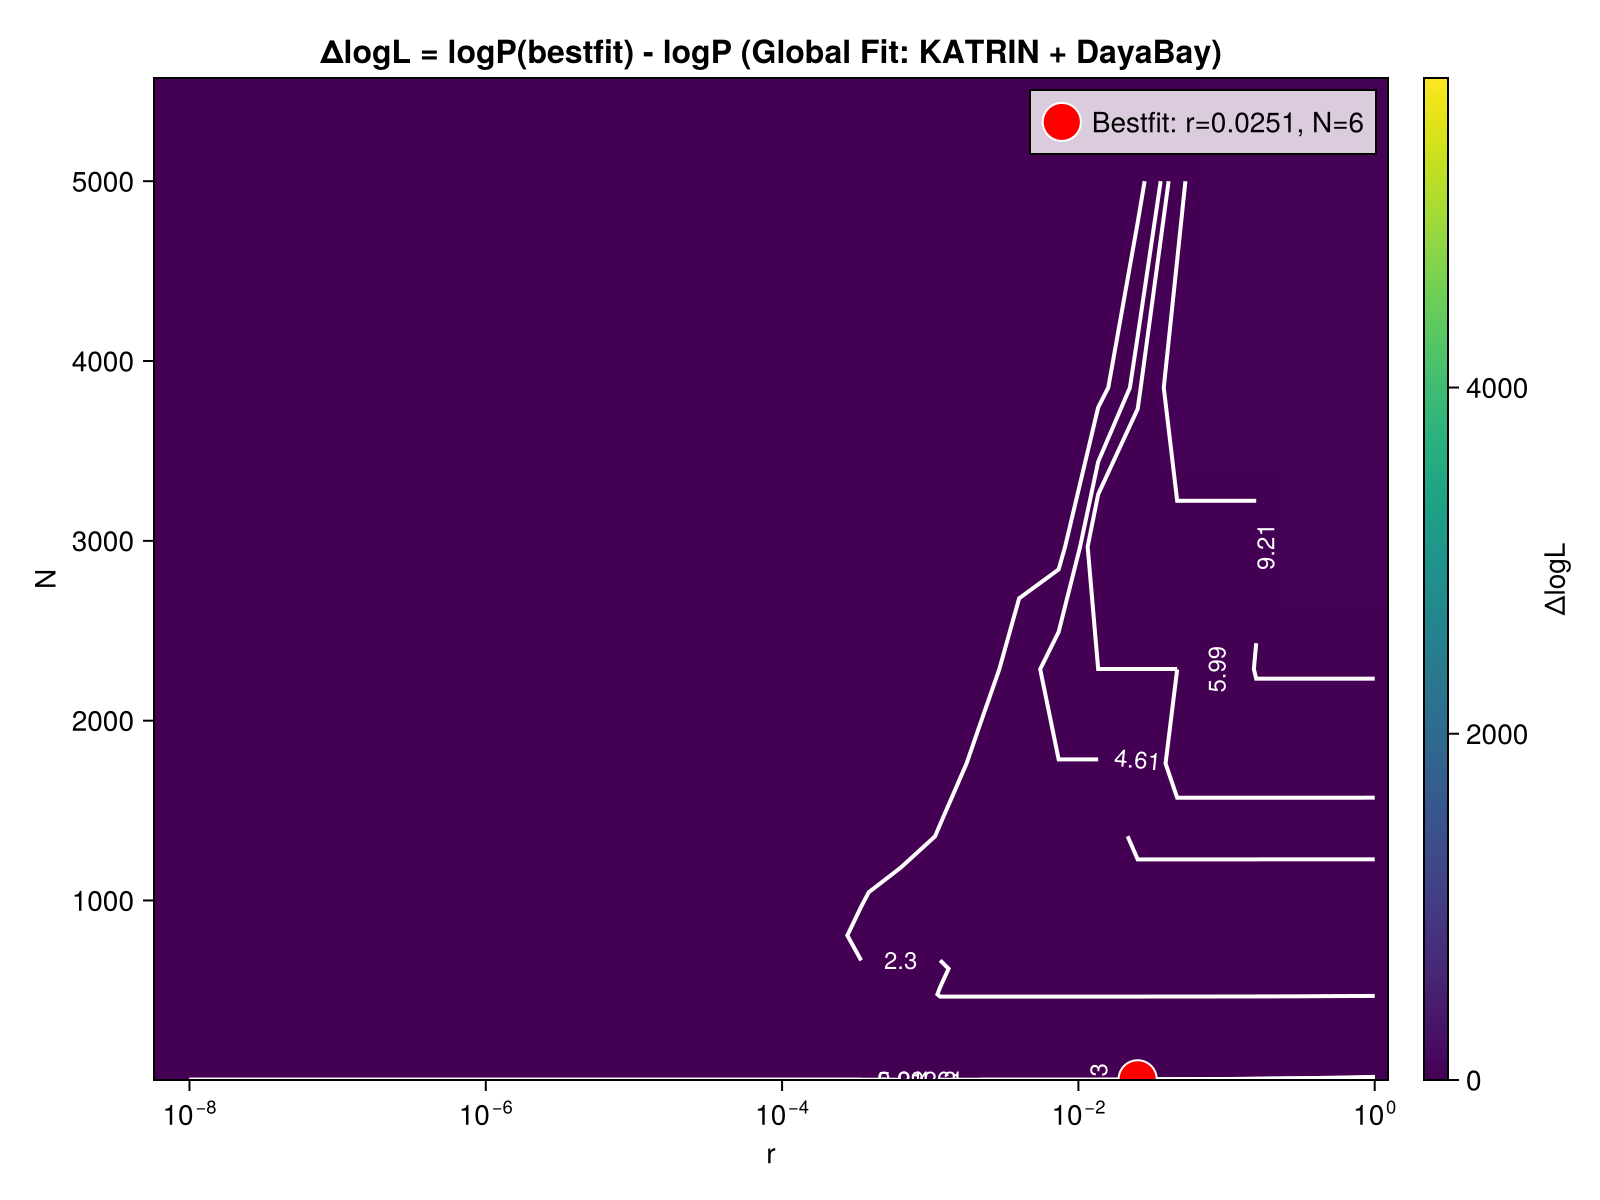

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbo

Saved to: both_delta_logl.png


┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can

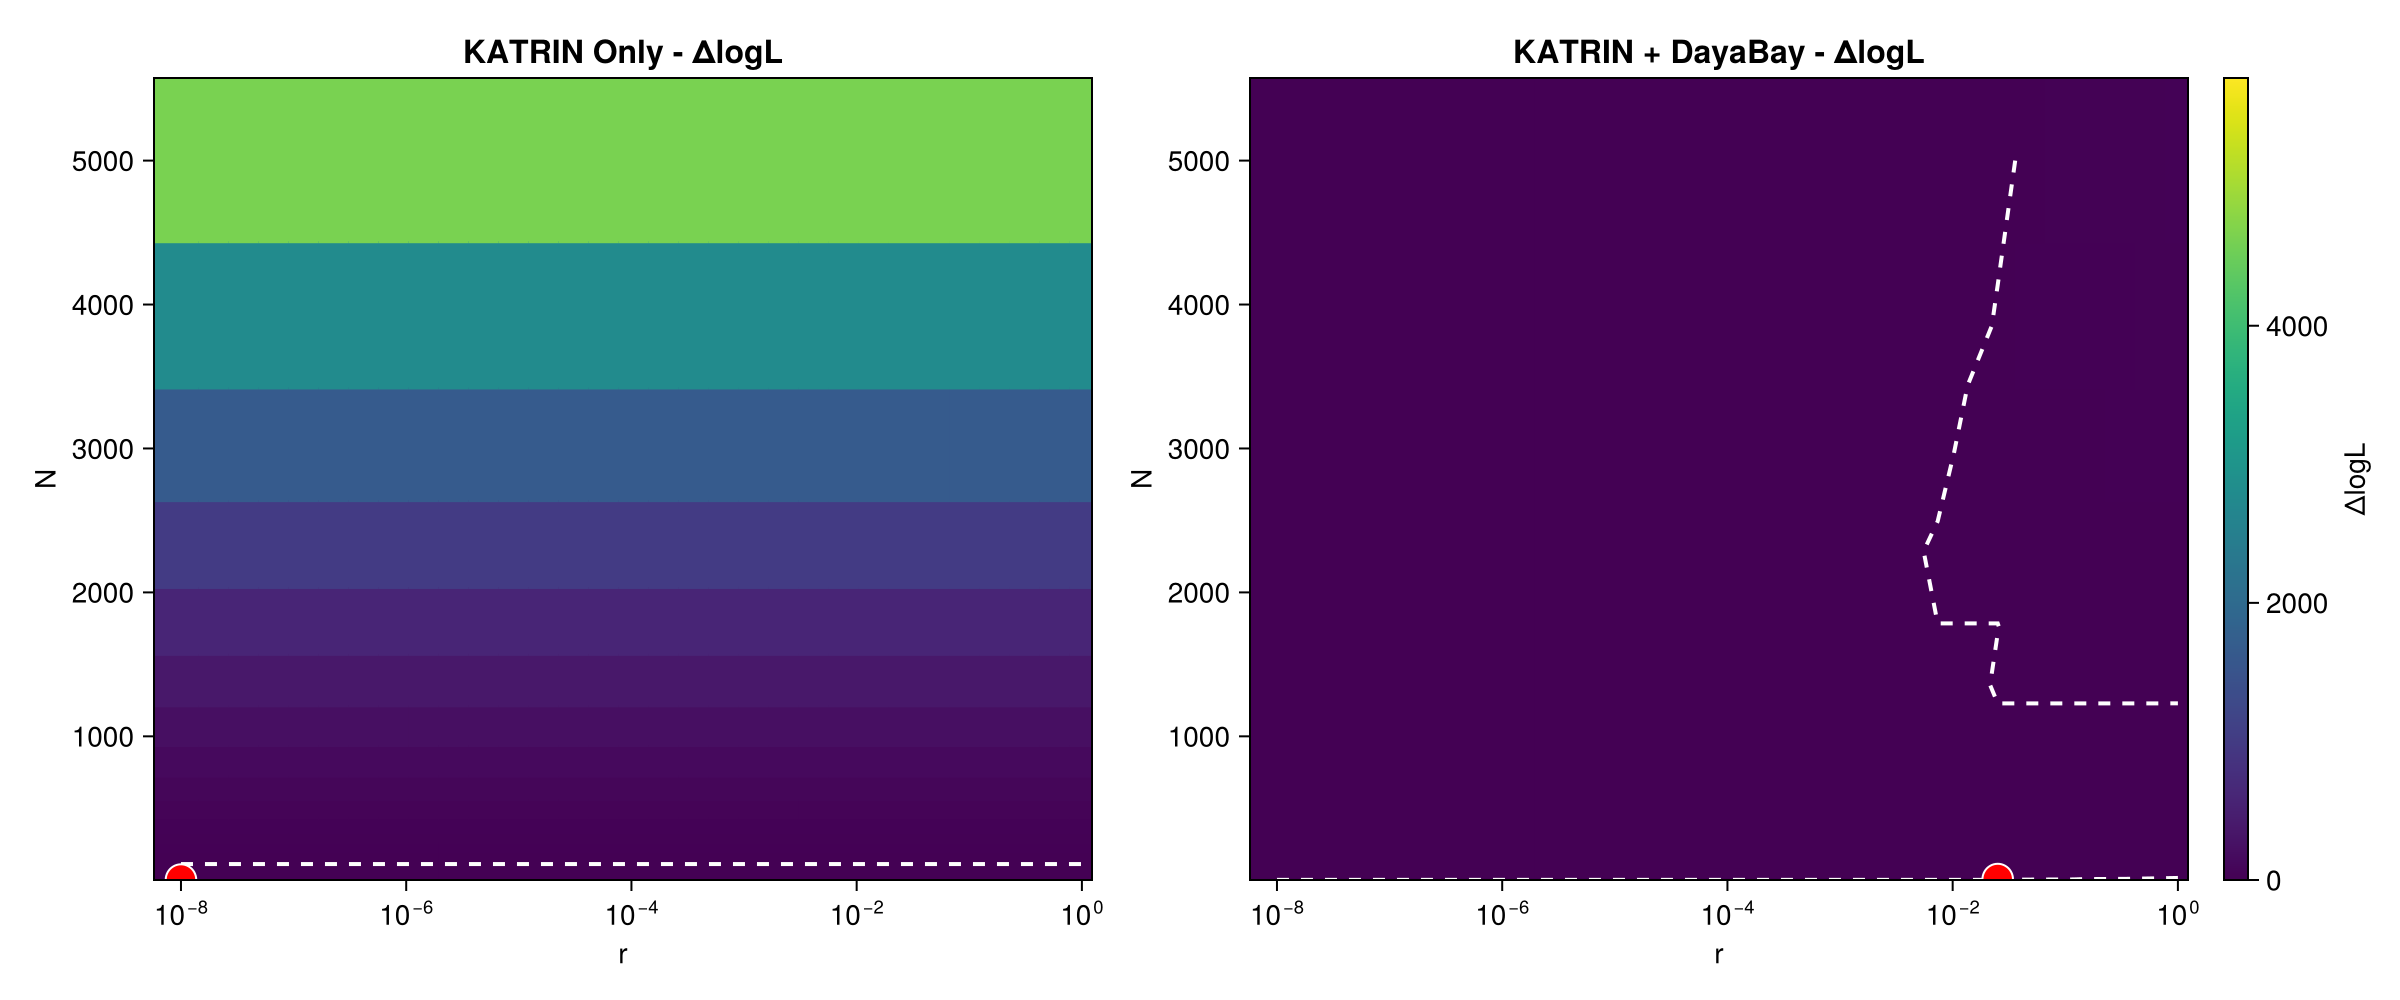

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


CairoMakie.Screen{IMAGE}


In [22]:
using JLD2
using CairoMakie
using ColorSchemes

function plot_delta_logl_global(
    global_file::String;
    save_path = nothing,
    log_scale_r = true,
    contour_levels = [2.3, 4.61, 5.99, 9.21],  # 68%, 90%, 95%, 99% CL for 2 dof
    contour_labels = ["68%", "90%", "95%", "99%"]
)
    # Load data
    data = load(global_file)
    result = haskey(data, "result") ? data["result"] : only(values(data))
    
    # Get grids and log-posterior
    r_vals = result.axes[1]
    N_vals = result.axes[2]
    
    # Check if it's log_posterior or llh
    if hasproperty(result.values, :log_posterior)
        logp = result.values.log_posterior
        label_name = "Log-Posterior"
    elseif hasproperty(result.values, :llh)
        logp = result.values.llh
        label_name = "Log-Likelihood"
    else
        error("Neither log_posterior nor llh found in result")
    end
    
    # Clean up infinite/NaN values
    logp_clean = copy(logp)
    logp_clean[.!isfinite.(logp_clean)] .= NaN
    
    # Find bestfit
    best_idx = argmax(logp_clean)
    best_r_idx = CartesianIndices(logp_clean)[best_idx][1]
    best_N_idx = CartesianIndices(logp_clean)[best_idx][2]
    best_r = r_vals[best_r_idx]
    best_N = N_vals[best_N_idx]
    best_logp = logp_clean[best_idx]
    
    # Calculate ΔlogL = bestfit - logp (so bestfit = 0)
    delta_logl = best_logp .- logp_clean
    delta_logl[delta_logl .< 0] .= 0  # Clamp small negative values due to numerical issues
    
    println("=== BESTFIT INFORMATION ===")
    println("Bestfit r = $best_r")
    println("Bestfit N = $best_N")
    println("Bestfit $label_name = $best_logp")
    println("ΔlogL range: $(minimum(skipmissing(delta_logl))) to $(maximum(skipmissing(delta_logl)))")
    
    # Create figure
    fig = Figure(size=(800, 600))
    
    # Set up axis
    ax = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "ΔlogL = logP(bestfit) - logP (Global Fit: KATRIN + DayaBay)",
        xscale = log_scale_r ? log10 : identity,
        yscale = identity,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    # Choose colormap
    cmap = cgrad(:viridis)
    
    # Plot heatmap of ΔlogL
    hm = heatmap!(
        ax,
        r_vals,
        N_vals,
        delta_logl,
        colormap = cmap,
        interpolate = false,
        nan_color = :gray
    )
    
    # Add contour lines
    if !isempty(contour_levels)
        max_delta = maximum(skipmissing(delta_logl))
        valid_levels = [lvl for lvl in contour_levels if lvl < max_delta]
        
        if !isempty(valid_levels)
            contour!(
                ax,
                r_vals,
                N_vals,
                delta_logl,
                levels = valid_levels,
                color = :white,
                linewidth = 2,
                linestyle = :solid,
                labels = true,
                labelcolor = :white,
                labelsize = 12
            )
        end
    end
    
    # Mark bestfit point
    scatter!(
        ax,
        [best_r],
        [best_N],
        color = :red,
        marker = :star,
        markersize = 25,
        strokewidth = 1,
        strokecolor = :white,
        label = "Bestfit: r=$(round(best_r, sigdigits=3)), N=$(round(Int, best_N))"
    )
    
    # Add colorbar
    Colorbar(fig[1, 2], hm, label = "ΔlogL")
    
    # Add legend
    axislegend(ax, position = :rt, framevisible = true, bgcolor = (:white, 0.8))
    
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig, delta_logl, (best_r, best_N)
end

# Function to plot ΔlogL for both scans side by side
function plot_both_delta_logl(
    katrin_file::String,
    global_file::String;
    save_path = nothing,
    log_scale_r = true
)
    # Load data
    katrin_data = load(katrin_file)
    global_data = load(global_file)
    
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    # KATRIN
    r_katrin = katrin_result.axes[1]
    N_katrin = katrin_result.axes[2]
    
    if hasproperty(katrin_result.values, :log_posterior)
        logp_katrin = katrin_result.values.log_posterior
    elseif hasproperty(katrin_result.values, :llh)
        logp_katrin = katrin_result.values.llh
    else
        error("No log_posterior or llh found")
    end
    
    logp_katrin[.!isfinite.(logp_katrin)] .= NaN
    best_katrin_idx = argmax(logp_katrin)
    best_katrin_logp = logp_katrin[best_katrin_idx]
    delta_katrin = best_katrin_logp .- logp_katrin
    delta_katrin[delta_katrin .< 0] .= 0
    
    # GLOBAL
    r_global = global_result.axes[1]
    N_global = global_result.axes[2]
    
    if hasproperty(global_result.values, :log_posterior)
        logp_global = global_result.values.log_posterior
    elseif hasproperty(global_result.values, :llh)
        logp_global = global_result.values.llh
    else
        error("No log_posterior or llh found")
    end
    
    logp_global[.!isfinite.(logp_global)] .= NaN
    best_global_idx = argmax(logp_global)
    best_global_logp = logp_global[best_global_idx]
    delta_global = best_global_logp .- logp_global
    delta_global[delta_global .< 0] .= 0
    
    # Find common color range
    max_delta = max(maximum(skipmissing(delta_katrin)), maximum(skipmissing(delta_global)))
    
    # Create figure with two panels
    fig = Figure(size=(1200, 500))
    
    # Panel 1: KATRIN only
    ax1 = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN Only - ΔlogL",
        xscale = log_scale_r ? log10 : identity,
        yscale = identity,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm1 = heatmap!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # Add contour for 90% CL
    contour!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        levels = [4.61],
        color = :white,
        linewidth = 2,
        linestyle = :dash,
        labels = false
    )
    
    # Mark bestfit
    best_katrin_pos = argmax(logp_katrin)
    best_katrin_r_idx = CartesianIndices(logp_katrin)[best_katrin_pos][1]
    best_katrin_N_idx = CartesianIndices(logp_katrin)[best_katrin_pos][2]
    scatter!(
        ax1,
        [r_katrin[best_katrin_r_idx]],
        [N_katrin[best_katrin_N_idx]],
        color = :red,
        marker = :star,
        markersize = 20,
        strokewidth = 1,
        strokecolor = :white
    )
    
    # Panel 2: Combined
    ax2 = Axis(
        fig[1, 2],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN + DayaBay - ΔlogL",
        xscale = log_scale_r ? log10 : identity,
        yscale = identity,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm2 = heatmap!(
        ax2,
        r_global,
        N_global,
        delta_global,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # Add contour for 90% CL
    contour!(
        ax2,
        r_global,
        N_global,
        delta_global,
        levels = [4.61],
        color = :white,
        linewidth = 2,
        linestyle = :dash,
        labels = false
    )
    
    # Mark bestfit
    best_global_pos = argmax(logp_global)
    best_global_r_idx = CartesianIndices(logp_global)[best_global_pos][1]
    best_global_N_idx = CartesianIndices(logp_global)[best_global_pos][2]
    scatter!(
        ax2,
        [r_global[best_global_r_idx]],
        [N_global[best_global_N_idx]],
        color = :red,
        marker = :star,
        markersize = 20,
        strokewidth = 1,
        strokecolor = :white
    )
    
    # Shared colorbar
    Colorbar(fig[1, 3], hm1, label = "ΔlogL")
    
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig
end

# Usage
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_lognew_m0=0.01.jld2"
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_IO_man_m0=0.01.jld2"

# Plot ΔlogL for global fit only
fig1, delta, best = plot_delta_logl_global(
    global_file;
    save_path = "global_delta_logl.png",
    log_scale_r = true
)
display(fig1)

# Plot both side by side
fig2 = plot_both_delta_logl(
    katrin_file,
    global_file;
    save_path = "both_delta_logl.png",
    log_scale_r = true
)
display(fig2)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


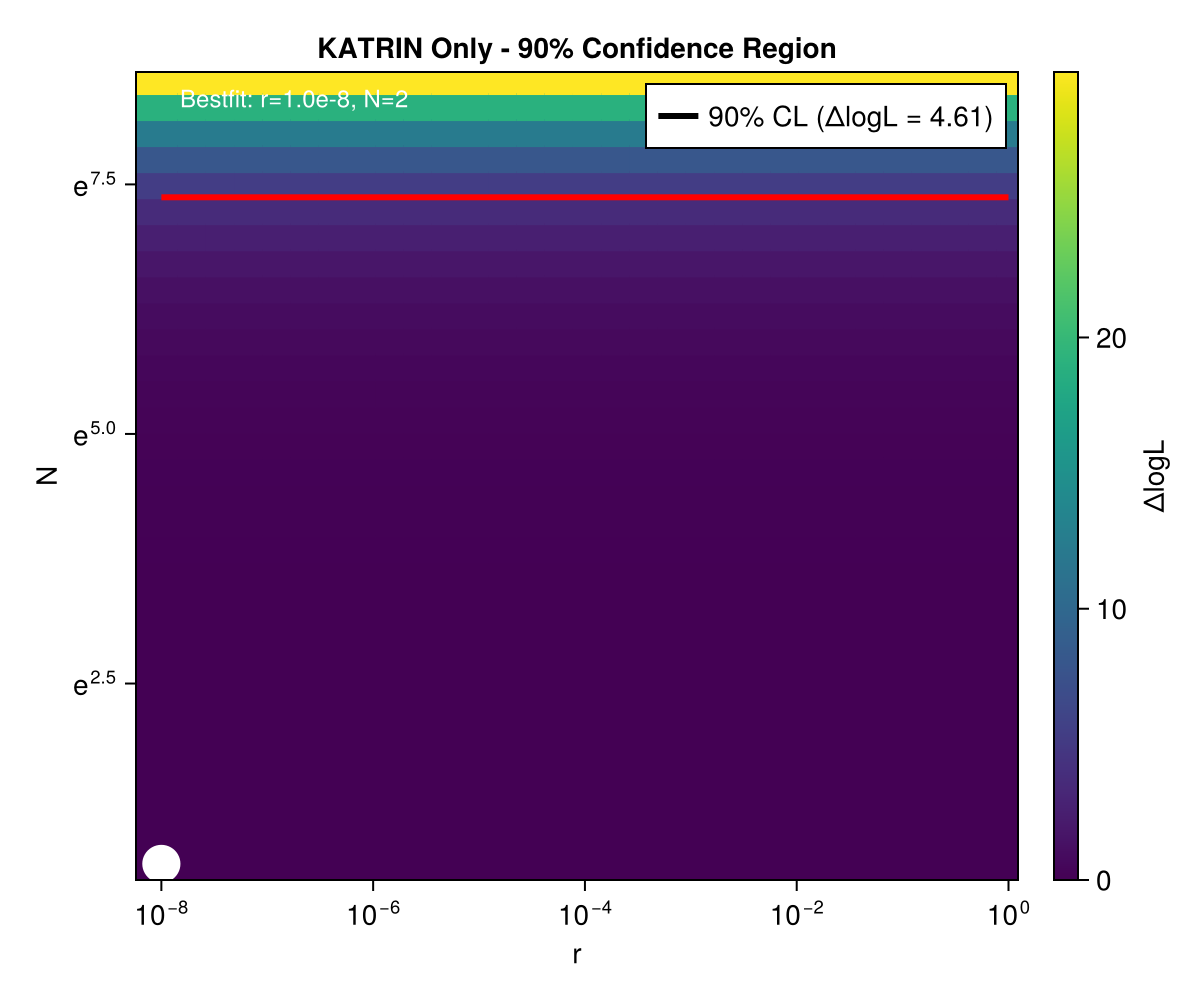

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


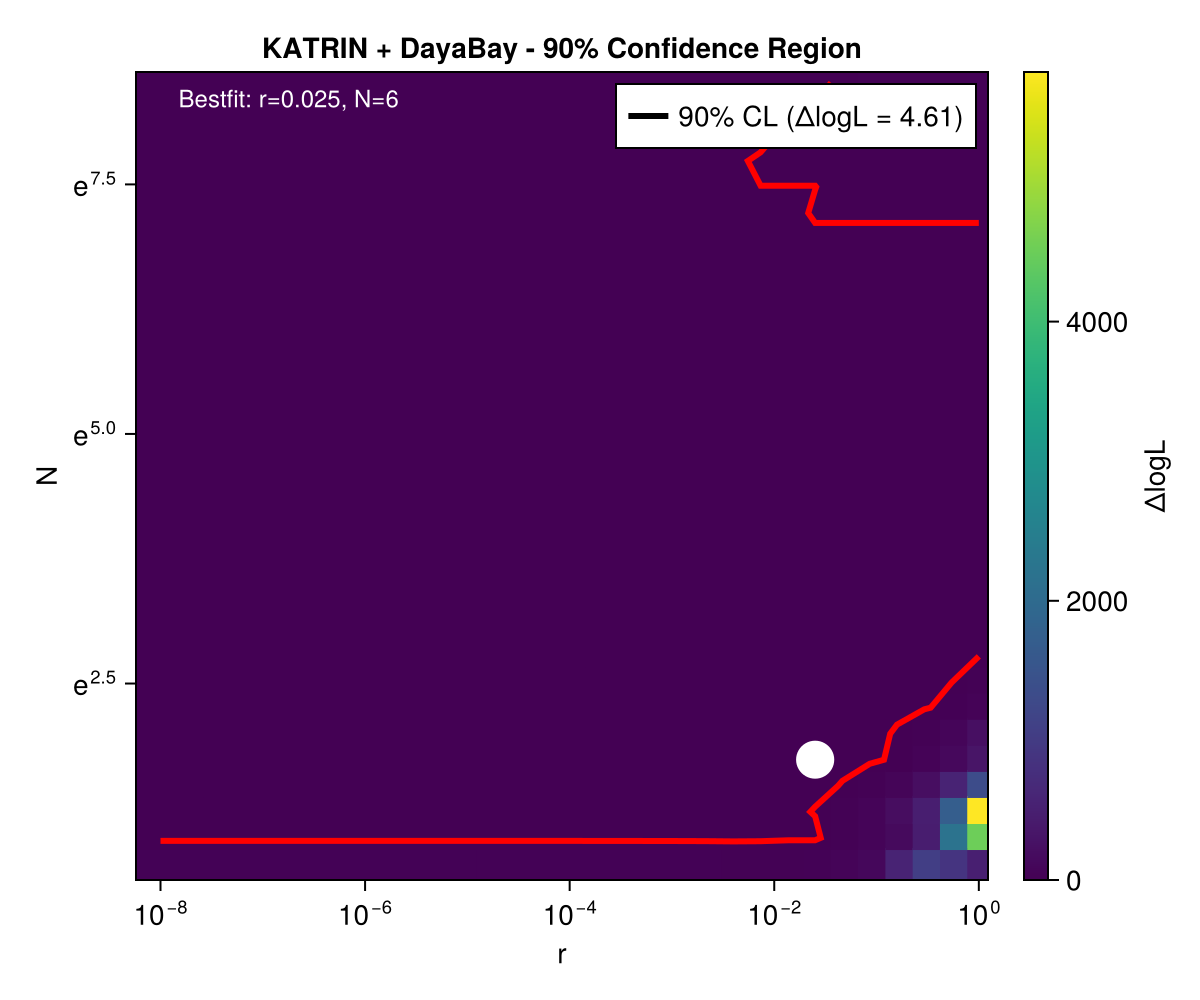

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


CairoMakie.Screen{IMAGE}


In [30]:
using JLD2
using CairoMakie

function plot_confidence_contours(
    file_path::String,
    experiment_name::String;
    save_path = nothing,
    log_scale_r = true
)
    # Load data
    data = load(file_path)
    result = haskey(data, "result") ? data["result"] : only(values(data))
    
    # Get data
    r_vals = result.axes[1]
    N_vals = result.axes[2]
    
    if hasproperty(result.values, :log_posterior)
        logp = result.values.log_posterior
    else
        logp = result.values.llh
    end
    
    # Clean up
    logp[.!isfinite.(logp)] .= NaN
    
    # Find bestfit
    best_idx = argmax(logp)
    best_r = r_vals[CartesianIndices(logp)[best_idx][1]]
    best_N = N_vals[CartesianIndices(logp)[best_idx][2]]
    best_logp = logp[best_idx]
    
    # Calculate ΔlogL
    delta = best_logp .- logp
    delta[delta .< 0] .= 0
    
    # Create plot
    fig = Figure(size=(600, 500))
    ax = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "$experiment_name - 90% Confidence Region",
        xscale = log_scale_r ? log10 : identity,
        titlesize = 14,
        yscale=log
    )
    
    # Plot heatmap
    hm = heatmap!(ax, r_vals, N_vals, delta, colormap = :viridis)
    
    # Draw 90% confidence contour (ΔlogL = 4.61)
    contour!(
        ax,
        r_vals, N_vals, delta,
        levels = [4.61],
        color = :red,
        linewidth = 3,
        label = "90% CL (ΔlogL = 4.61)"
    )
    
    # Mark bestfit
    scatter!(ax, [best_r], [best_N], color = :white, marker = :star, markersize = 25)
    
    # Add colorbar
    Colorbar(fig[1, 2], hm, label = "ΔlogL")
    axislegend(ax, position = :rt)
    
    # Add text with bestfit info
    text!(
        ax,
        0.05, 0.95,
        text = "Bestfit: r=$(round(best_r, sigdigits=2)), N=$(round(Int, best_N))",
        space = :relative,
        color = :white,
        fontsize = 12
    )
    
    if save_path !== nothing
        save(save_path, fig)
    end
    
    return fig
end

# Plot both
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_man_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_lognew_m0=0.01.jld2"

fig1 = plot_confidence_contours(katrin_file, "KATRIN Only")
display(fig1)

fig2 = plot_confidence_contours(global_file, "KATRIN + DayaBay")
display(fig2)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/makielayout/blocks/legend.jl:62
┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/makielayout/blocks/legend.jl:62


Saved to: both_contours_logN.png


┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can

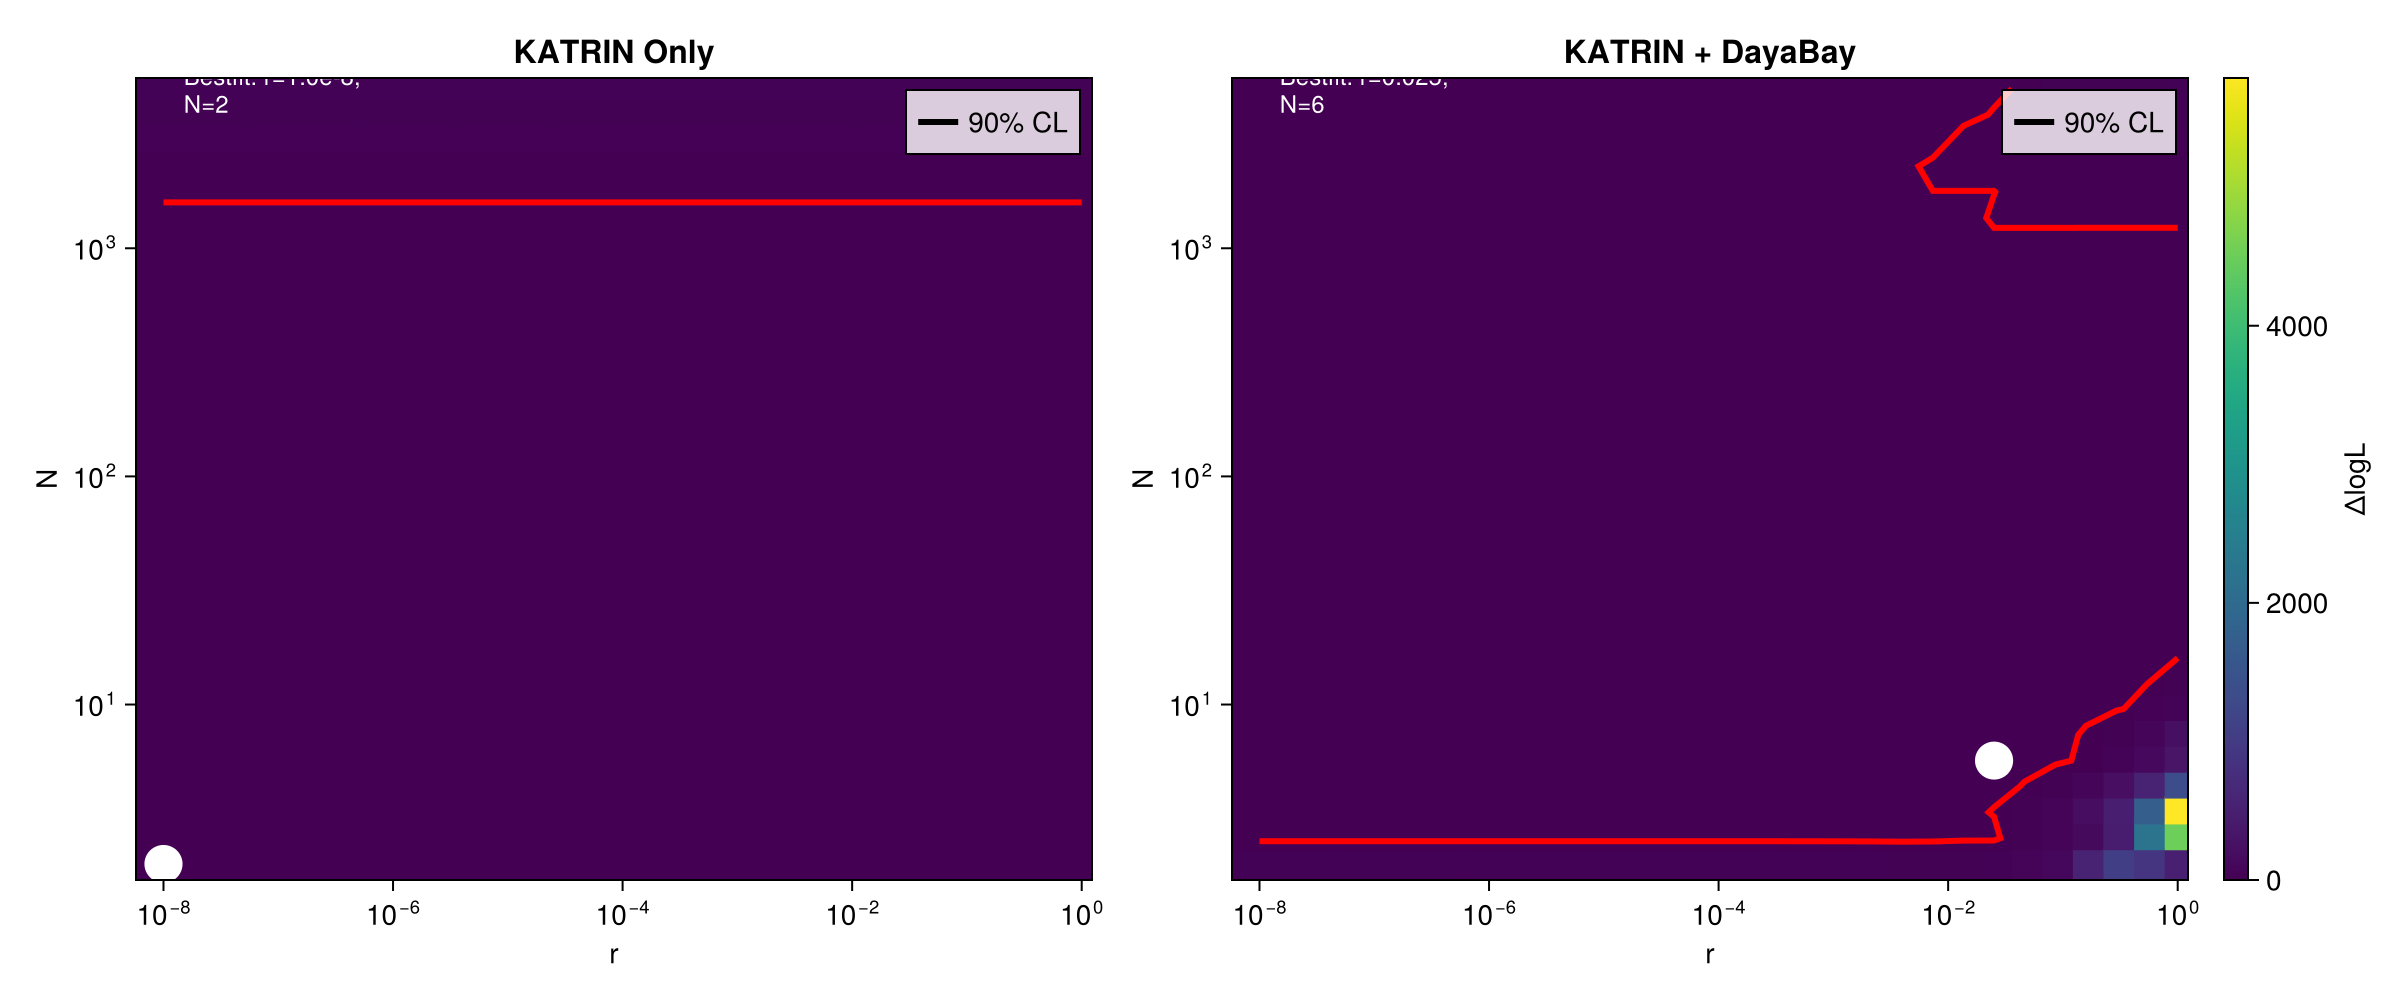

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


CairoMakie.Screen{IMAGE}


In [24]:
using JLD2
using CairoMakie

function plot_both_confidence_contours(
    katrin_file::String,
    global_file::String;
    save_path = nothing,
    log_scale_r = true,
    log_scale_N = true
)
    # Load KATRIN data
    katrin_data = load(katrin_file)
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    
    r_katrin = katrin_result.axes[1]
    N_katrin = katrin_result.axes[2]
    
    if hasproperty(katrin_result.values, :log_posterior)
        logp_katrin = katrin_result.values.log_posterior
    else
        logp_katrin = katrin_result.values.llh
    end
    
    logp_katrin[.!isfinite.(logp_katrin)] .= NaN
    best_katrin_idx = argmax(logp_katrin)
    best_katrin_r = r_katrin[CartesianIndices(logp_katrin)[best_katrin_idx][1]]
    best_katrin_N = N_katrin[CartesianIndices(logp_katrin)[best_katrin_idx][2]]
    best_katrin_logp = logp_katrin[best_katrin_idx]
    delta_katrin = best_katrin_logp .- logp_katrin
    delta_katrin[delta_katrin .< 0] .= 0
    
    # Load GLOBAL data
    global_data = load(global_file)
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    r_global = global_result.axes[1]
    N_global = global_result.axes[2]
    
    if hasproperty(global_result.values, :log_posterior)
        logp_global = global_result.values.log_posterior
    else
        logp_global = global_result.values.llh
    end
    
    logp_global[.!isfinite.(logp_global)] .= NaN
    best_global_idx = argmax(logp_global)
    best_global_r = r_global[CartesianIndices(logp_global)[best_global_idx][1]]
    best_global_N = N_global[CartesianIndices(logp_global)[best_global_idx][2]]
    best_global_logp = logp_global[best_global_idx]
    delta_global = best_global_logp .- logp_global
    delta_global[delta_global .< 0] .= 0
    
    # Find common color range for fair comparison
    max_delta = max(maximum(skipmissing(delta_katrin)), maximum(skipmissing(delta_global)))
    
    # Create figure with two panels
    fig = Figure(size=(1200, 500))
    
    # Set up scales
    xscale = log_scale_r ? log10 : identity
    yscale = log_scale_N ? log10 : identity
    
    # Panel 1: KATRIN only
    ax1 = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN Only",
        xscale = xscale,
        yscale = yscale,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm1 = heatmap!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # 90% contour
    contour!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        levels = [4.61],
        color = :red,
        linewidth = 3,
        label = "90% CL"
    )
    
    # Bestfit marker
    scatter!(
        ax1,
        [best_katrin_r],
        [best_katrin_N],
        color = :white,
        marker = :star,
        markersize = 25
    )
    
    # Panel 2: Combined
    ax2 = Axis(
        fig[1, 2],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN + DayaBay",
        xscale = xscale,
        yscale = yscale,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm2 = heatmap!(
        ax2,
        r_global,
        N_global,
        delta_global,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # 90% contour
    contour!(
        ax2,
        r_global,
        N_global,
        delta_global,
        levels = [4.61],
        color = :red,
        linewidth = 3,
        label = "90% CL"
    )
    
    # Bestfit marker
    scatter!(
        ax2,
        [best_global_r],
        [best_global_N],
        color = :white,
        marker = :star,
        markersize = 25
    )
    
    # Shared colorbar
    Colorbar(fig[1, 3], hm1, label = "ΔlogL")
    
    # Add legends
    axislegend(ax1, position = :rt, framevisible = true, bgcolor = (:white, 0.8))
    axislegend(ax2, position = :rt, framevisible = true, bgcolor = (:white, 0.8))
    
    # Add text with bestfit info
    text!(
        ax1,
        0.05, 0.95,
        text = "Bestfit: r=$(round(best_katrin_r, sigdigits=2)),\nN=$(round(Int, best_katrin_N))",
        space = :relative,
        color = :white,
        fontsize = 12
    )
    
    text!(
        ax2,
        0.05, 0.95,
        text = "Bestfit: r=$(round(best_global_r, sigdigits=2)),\nN=$(round(Int, best_global_N))",
        space = :relative,
        color = :white,
        fontsize = 12
    )
    
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig
end

# Plot both side by side
fig = plot_both_confidence_contours(
    katrin_file,
    global_file;
    log_scale_r = true,
    log_scale_N = true,
    save_path = "both_contours_logN.png"
)
display(fig)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/makielayout/blocks/legend.jl:62
┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/makielayout/blocks/legend.jl:62


Saved to: both_contours_logN.png


┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


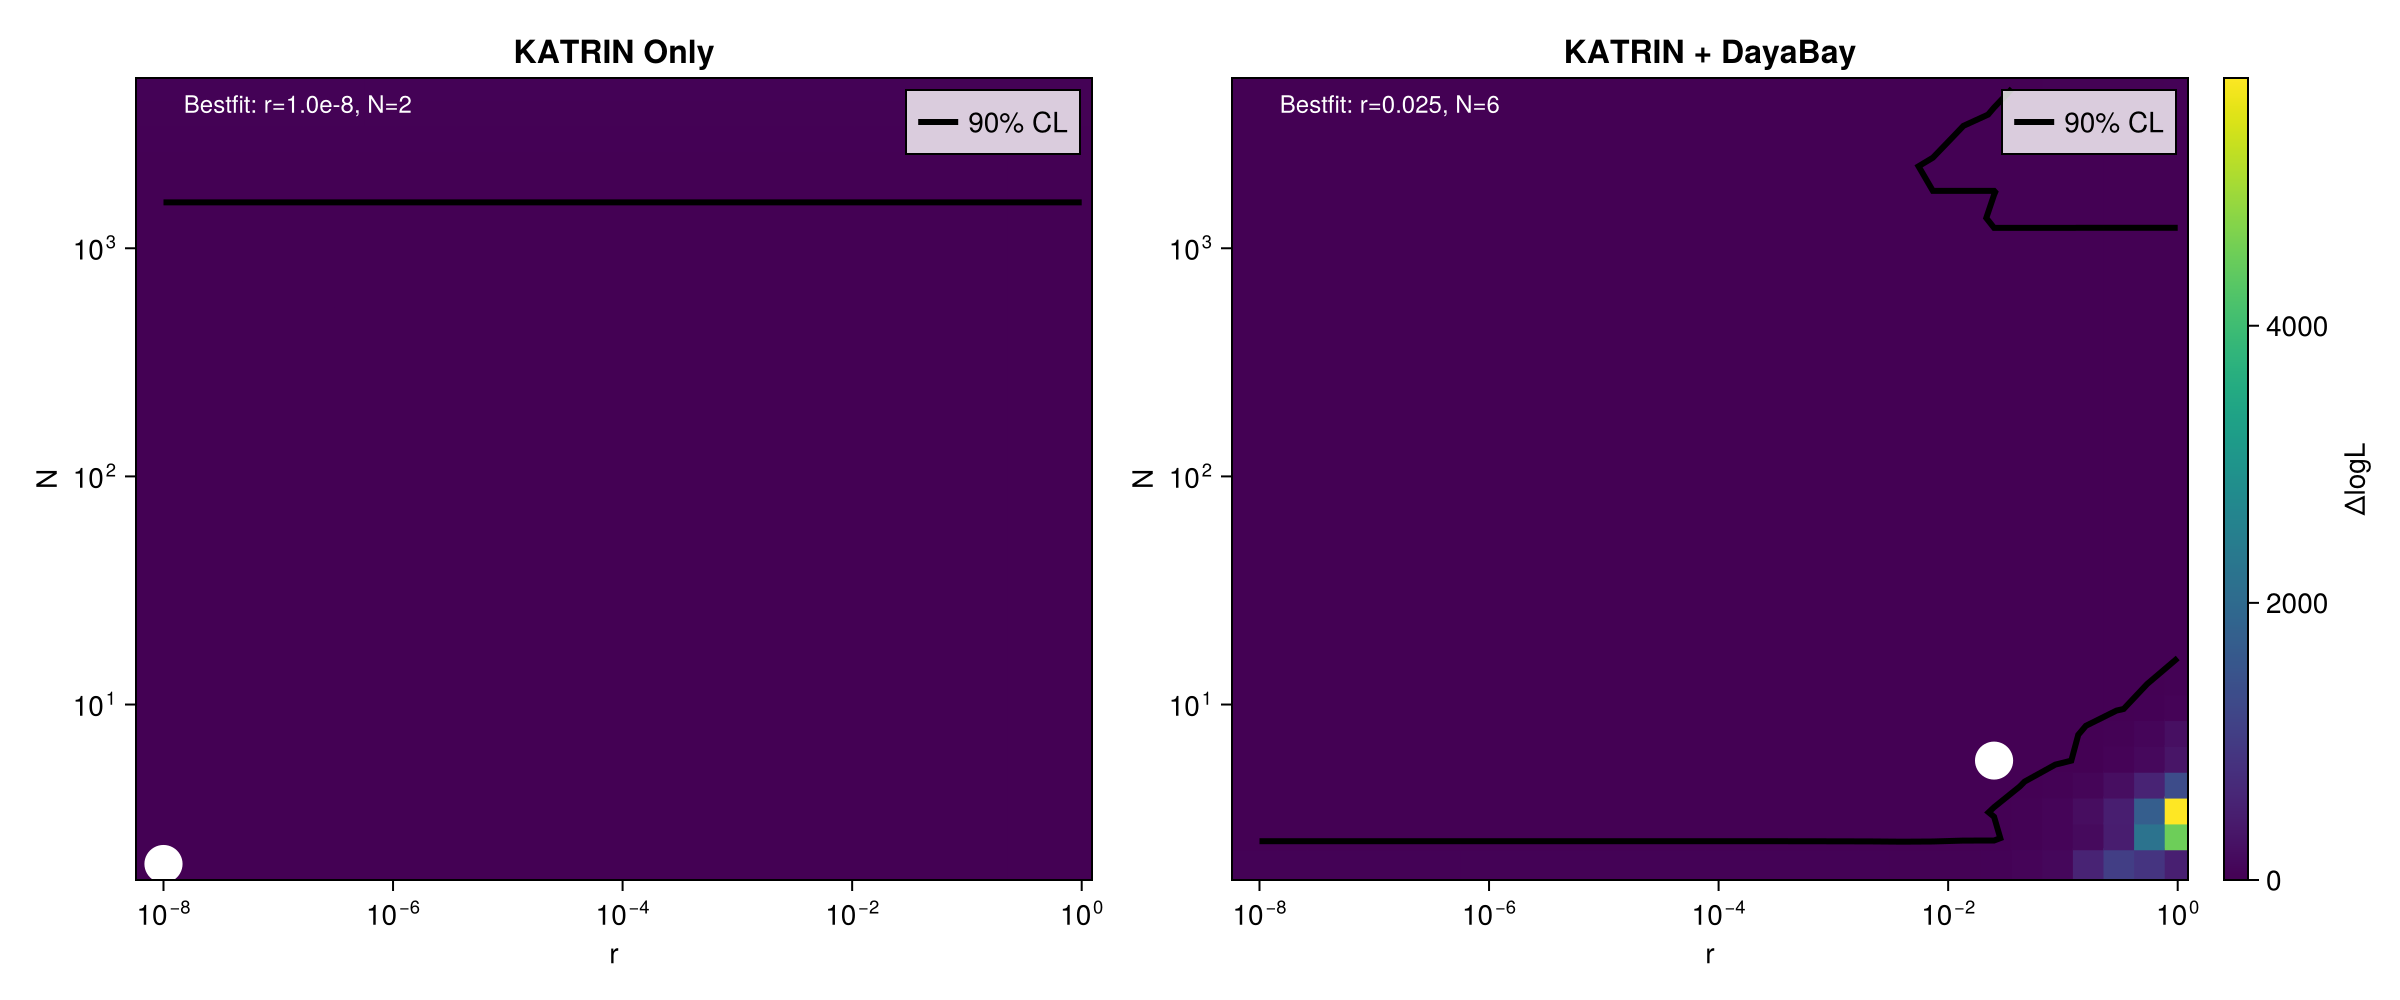

┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975
┌ Warning: Unsupported marker: star, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1975


In [25]:
using JLD2
using CairoMakie

function plot_both_confidence_contours(
    katrin_file::String,
    global_file::String;
    save_path = nothing,
    log_scale_r = true,
    log_scale_N = true
)
    # Load KATRIN data
    katrin_data = load(katrin_file)
    katrin_result = haskey(katrin_data, "result") ? katrin_data["result"] : only(values(katrin_data))
    
    r_katrin = katrin_result.axes[1]
    N_katrin = katrin_result.axes[2]
    
    if hasproperty(katrin_result.values, :log_posterior)
        logp_katrin = katrin_result.values.log_posterior
    else
        logp_katrin = katrin_result.values.llh
    end
    
    logp_katrin[.!isfinite.(logp_katrin)] .= NaN
    best_katrin_idx = argmax(logp_katrin)
    best_katrin_r = r_katrin[CartesianIndices(logp_katrin)[best_katrin_idx][1]]
    best_katrin_N = N_katrin[CartesianIndices(logp_katrin)[best_katrin_idx][2]]
    best_katrin_logp = logp_katrin[best_katrin_idx]
    delta_katrin = best_katrin_logp .- logp_katrin
    delta_katrin[delta_katrin .< 0] .= 0
    
    # Load GLOBAL data
    global_data = load(global_file)
    global_result = haskey(global_data, "result") ? global_data["result"] : only(values(global_data))
    
    r_global = global_result.axes[1]
    N_global = global_result.axes[2]
    
    if hasproperty(global_result.values, :log_posterior)
        logp_global = global_result.values.log_posterior
    else
        logp_global = global_result.values.llh
    end
    
    logp_global[.!isfinite.(logp_global)] .= NaN
    best_global_idx = argmax(logp_global)
    best_global_r = r_global[CartesianIndices(logp_global)[best_global_idx][1]]
    best_global_N = N_global[CartesianIndices(logp_global)[best_global_idx][2]]
    best_global_logp = logp_global[best_global_idx]
    delta_global = best_global_logp .- logp_global
    delta_global[delta_global .< 0] .= 0
    
    # Find common color range for fair comparison
    max_delta = max(maximum(skipmissing(delta_katrin)), maximum(skipmissing(delta_global)))
    
    # Create figure with two panels
    fig = Figure(size=(1200, 500))
    
    # Set up scales
    xscale = log_scale_r ? log10 : identity
    yscale = log_scale_N ? log10 : identity
    
    # Panel 1: KATRIN only
    ax1 = Axis(
        fig[1, 1],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN Only",
        xscale = xscale,
        yscale = yscale,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm1 = heatmap!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # 90% contour
    contour!(
        ax1,
        r_katrin,
        N_katrin,
        delta_katrin,
        levels = [4.61],
        color = :black,
        linewidth = 3,
        label = "90% CL"
    )
    
    # Bestfit marker
    scatter!(
        ax1,
        [best_katrin_r],
        [best_katrin_N],
        color = :white,
        marker = :star,
        markersize = 25
    )
    
    # Panel 2: Combined
    ax2 = Axis(
        fig[1, 2],
        xlabel = "r",
        ylabel = "N",
        title = "KATRIN + DayaBay",
        xscale = xscale,
        yscale = yscale,
        titlesize = 16,
        xlabelsize = 14,
        ylabelsize = 14
    )
    
    hm2 = heatmap!(
        ax2,
        r_global,
        N_global,
        delta_global,
        colormap = :viridis,
        colorrange = (0, max_delta),
        interpolate = false,
        nan_color = :gray
    )
    
    # 90% contour
    contour!(
        ax2,
        r_global,
        N_global,
        delta_global,
        levels = [4.61],
        color = :black,
        linewidth = 3,
        label = "90% CL"
    )
    
    # Bestfit marker
    scatter!(
        ax2,
        [best_global_r],
        [best_global_N],
        color = :white,
        marker = :star,
        markersize = 25
    )
    
    # Shared colorbar
    Colorbar(fig[1, 3], hm1, label = "ΔlogL")
    
    # Add legends - moved lower (valign = :bottom instead of :top)
    axislegend(ax1, position = :rt, framevisible = true, bgcolor = (:white, 0.8), valign = :top)
    axislegend(ax2, position = :rt, framevisible = true, bgcolor = (:white, 0.8), valign = :top)
    
    # Add text with bestfit info (unchanged)
    text!(
        ax1,
        0.05, 0.95,
        text = "Bestfit: r=$(round(best_katrin_r, sigdigits=2)), N=$(round(Int, best_katrin_N))",
        space = :relative,
        color = :white,
        fontsize = 12
    )
    
    text!(
        ax2,
        0.05, 0.95,
        text = "Bestfit: r=$(round(best_global_r, sigdigits=2)), N=$(round(Int, best_global_N))",
        space = :relative,
        color = :white,
        fontsize = 12
    )
    
    if save_path !== nothing
        save(save_path, fig)
        println("Saved to: $save_path")
    end
    
    return fig
end

# Usage
katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_man_m0=0.01.jld2"
global_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_lognew_m0=0.01.jld2"

# Plot both side by side
fig = plot_both_confidence_contours(
    katrin_file,
    global_file;
    log_scale_r = true,
    log_scale_N = true,
    save_path = "both_contours_logN.png"
)
display("image/png", fig)

In [20]:
using JLD2

# File paths
#katrin_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2"
dayabay_file = "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NNM_IO_log_m0=0.01.jld2"

# Load data
#katrin_data = load(katrin_file)
dayabay_data = load(dayabay_file)

# Extract results
#katrin_result = katrin_data["result"]
dayabay_result = dayabay_data["result"]

# Get log-posterior matrices
#katrin_logp = katrin_result.values.log_posterior
dayabay_logp = dayabay_result.values.log_posterior

# Grid information
#r_vals = katrin_result.axes[1]
#N_vals = katrin_result.axes[2]

println("=== GRID INFORMATION ===")
println("r[1] = $(r_vals[1]) (smallest r)")
println("r[31] = $(r_vals[31]) (largest r)")
println("N[1] = $(N_vals[1]) (smallest N)")
println("N[31] = $(N_vals[31]) (largest N)")

# DayaBay statistics
println("\n=== DAYABAY ONLY ===")
dayabay_min_llh = minimum(dayabay_logp)
dayabay_max_llh = maximum(dayabay_logp)
println("Min log-posterior: $dayabay_min_llh")
println("Max log-posterior: $dayabay_max_llh")

# Find DayaBay bestfit point
dayabay_best_idx = argmax(dayabay_logp)
dayabay_best_r_idx = CartesianIndices(dayabay_logp)[dayabay_best_idx][1]
dayabay_best_N_idx = CartesianIndices(dayabay_logp)[dayabay_best_idx][2]
dayabay_best_r = r_vals[dayabay_best_r_idx]
dayabay_best_N = N_vals[dayabay_best_N_idx]
dayabay_best_logp = dayabay_logp[dayabay_best_idx]

println("\nDayaBay bestfit:")
println("  Position: (r_idx=$dayabay_best_r_idx, N_idx=$dayabay_best_N_idx)")
println("  r = $dayabay_best_r")
println("  N = $dayabay_best_N")
println("  log-posterior = $dayabay_best_logp")

# DayaBay at corner point (r_idx=1, N_idx=31)
corner_r_idx = 1
corner_N_idx = 31
dayabay_corner_logp = dayabay_logp[corner_r_idx, corner_N_idx]

println("\nDayaBay at corner point (r_idx=1, N_idx=31):")
println("  r = $(r_vals[corner_r_idx])")
println("  N = $(N_vals[corner_N_idx])")
println("  log-posterior = $dayabay_corner_logp")

# Calculate difference from bestfit to corner
dayabay_delta_corner = dayabay_best_logp - dayabay_corner_logp
println("\nDifference (bestfit - corner): $dayabay_delta_corner")
println("  (Positive means bestfit is better than corner)")

# 2ΔlogL for 90% CL comparison
sigma_90 = 4.61
dayabay_2delta_corner = 2 * dayabay_delta_corner
println("\n2ΔlogL at corner point: $dayabay_2delta_corner")

if dayabay_2delta_corner < sigma_90
    println("  → DayaBay: corner point is INSIDE 90% CL contour")
else
    println("  → DayaBay: corner point is OUTSIDE 90% CL contour")
end

# For comparison - KATRIN at same corner
println("\n=== FOR COMPARISON - KATRIN ONLY ===")
katrin_min_llh = minimum(katrin_logp)
katrin_max_llh = maximum(katrin_logp)
println("Min log-posterior: $katrin_min_llh")
println("Max log-posterior: $katrin_max_llh")

katrin_best_idx = argmax(katrin_logp)
katrin_best_r_idx = CartesianIndices(katrin_logp)[katrin_best_idx][1]
katrin_best_N_idx = CartesianIndices(katrin_logp)[katrin_best_idx][2]
katrin_best_r = r_vals[katrin_best_r_idx]
katrin_best_N = N_vals[katrin_best_N_idx]
katrin_best_logp = katrin_logp[katrin_best_idx]

println("\nKATRIN bestfit:")
println("  Position: (r_idx=$katrin_best_r_idx, N_idx=$katrin_best_N_idx)")
println("  r = $katrin_best_r")
println("  N = $katrin_best_N")
println("  log-posterior = $katrin_best_logp")

katrin_corner_logp = katrin_logp[corner_r_idx, corner_N_idx]
println("\nKATRIN at corner point:")
println("  log-posterior = $katrin_corner_logp")

katrin_delta_corner = katrin_best_logp - katrin_corner_logp
println("\nDifference (bestfit - corner): $katrin_delta_corner")

# Summary comparison
println("\n=== SUMMARY COMPARISON ===")
println("                    DayaBay Only     KATRIN Only")
println("Bestfit logp:       $dayabay_best_logp     $katrin_best_logp")
println("Corner logp:        $dayabay_corner_logp     $katrin_corner_logp")
println("ΔlogP (best-corner): $dayabay_delta_corner     $katrin_delta_corner")
println("2ΔlogL (corner):    $dayabay_2delta_corner     $(2*katrin_delta_corner)")
println("Inside 90% CL?      $(dayabay_2delta_corner < sigma_90 ? "YES" : "NO")          $(2*katrin_delta_corner < sigma_90 ? "YES" : "NO")")

println("\n=== INTERPRETATION ===")
if dayabay_2delta_corner > sigma_90 && 2*katrin_delta_corner < sigma_90
    println("✓ DayaBay EXCLUDES the corner point (r=1e-8, N=5000) at 90% CL")
    println("✓ KATRIN alone does NOT exclude this point")
    println("→ DayaBay has constraining power on sterile parameters despite having no expected sensitivity!")
    println("→ This indicates DayaBay's likelihood has unintended dependence on r and N")
elseif dayabay_2delta_corner < sigma_90 && 2*katrin_delta_corner < sigma_90
    println("Both scans include the corner point within 90% CL")
elseif dayabay_2delta_corner > sigma_90 && 2*katrin_delta_corner > sigma_90
    println("Both scans exclude the corner point")
end

=== GRID INFORMATION ===
r[1] = 1.0e-8 (smallest r)
r[31] = 1.0000000000000018 (largest r)
N[1] = 2.0 (smallest N)
N[31] = 4999.999999999999 (largest N)

=== DAYABAY ONLY ===
Min log-posterior: -18329.565882709172
Max log-posterior: -167.54829418027788

DayaBay bestfit:
  Position: (r_idx=26, N_idx=7)
  r = 0.04641588833612786
  N = 9.563524997900371
  log-posterior = -167.54829418027788

DayaBay at corner point (r_idx=1, N_idx=31):
  r = 1.0e-8
  N = 4999.999999999999
  log-posterior = -169.5475644719943

Difference (bestfit - corner): 1.9992702917164138
  (Positive means bestfit is better than corner)

2ΔlogL at corner point: 3.9985405834328276
  → DayaBay: corner point is INSIDE 90% CL contour

=== FOR COMPARISON - KATRIN ONLY ===
Min log-posterior: -29.24583540598007
Max log-posterior: 0.5399530744978267

KATRIN bestfit:
  Position: (r_idx=1, N_idx=31)
  r = 1.0e-8
  N = 4999.999999999999
  log-posterior = 0.5399530744978267

KATRIN at corner point:
  log-posterior = 0.539953074497

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
